# Active Preference Learning via Polytope Volume Removal

Instead of heuristic sample filtering, we maintain the feasible set $\Omega_t$ as an **explicit polytope** $\{\omega : A\omega \leq b\}$.

Each pairwise response (left, right, indifferent, incomparable) adds **linear constraints** on $\omega$,
and we select queries to **maximize expected volume removal** (Sadigh et al. 2017).

### Constraint rules (from the frame model)

Given query gaps $\Delta_j$ and thresholds $\tau, \tau'$:

| Response | Constraints on $\omega$ |
|----------|------------------------|
| **Left** ($Y \succ Y'$) | $\sum \omega_j |\Delta_j| \geq \tau$ and $\sum \omega_j (\Delta_j - \tau' |\Delta_j|) \geq 0$ |
| **Right** ($Y \prec Y'$) | $\sum \omega_j |\Delta_j| \geq \tau$ and $\sum \omega_j (\Delta_j + \tau' |\Delta_j|) \leq 0$ |
| **Indifferent** ($Y \sim Y'$) | $\sum \omega_j |\Delta_j| \leq \tau - \eta$ |
| **Incomparable** ($Y \bowtie Y'$) | $\sum \omega_j |\Delta_j| \geq \tau$, $\sum \omega_j (\Delta_j - \tau' |\Delta_j|) < 0$, $\sum \omega_j (\Delta_j + \tau' |\Delta_j|) > 0$ |

In [3]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog
from scipy.spatial.distance import pdist
from typing import List, Tuple, Optional, Set, Callable
from dataclasses import dataclass
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# ============================================================================
# Configuration
# ============================================================================

FEATURE_NAMES = ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']

FEATURE_RANGES = {
    'elderlyDep': (0, 5),
    'lifeYearsGained': (0, 25),
    'obesity': (0, 5),
    'weeklyWorkhours': (0, 50),
    'yearsWaiting': (1, 10)
}

# Algorithm parameters (can be changed at test time)
TAU = 0.1           # Intensity threshold
TAU_PRIME = 0.1     # Resolvability threshold
LAMBDA_X = 1.0      # Query scaling factor

print(f'Features: {FEATURE_NAMES}')
print(f'tau={TAU}, tau_prime={TAU_PRIME}, lambda_x={LAMBDA_X}')


# ============================================================================
# Data structures
# ============================================================================

@dataclass
class Patient:
    """Represents a patient with feature values."""
    elderlyDep: float
    lifeYearsGained: float
    obesity: float
    weeklyWorkhours: float
    yearsWaiting: float

    def to_array(self) -> np.ndarray:
        """Convert to numpy array in standard feature order."""
        return np.array([
            self.elderlyDep,
            self.lifeYearsGained,
            self.obesity,
            self.weeklyWorkhours,
            self.yearsWaiting
        ], dtype=float)

    @classmethod
    def from_array(cls, arr: np.ndarray) -> 'Patient':
        """Create Patient from numpy array."""
        return cls(
            elderlyDep=float(arr[0]),
            lifeYearsGained=float(arr[1]),
            obesity=float(arr[2]),
            weeklyWorkhours=float(arr[3]),
            yearsWaiting=float(arr[4])
        )

    def __repr__(self):
        return f"Patient(elder={self.elderlyDep}, life={self.lifeYearsGained}, " \
               f"obesity={self.obesity}, work={self.weeklyWorkhours}, wait={self.yearsWaiting})"


@dataclass
class PairwiseQuery:
    """Represents a pairwise comparison query."""
    patient_left: Patient
    patient_right: Patient
    context: Optional[str] = None

    def __repr__(self):
        return f"Query:\n  LEFT:  {self.patient_left}\n  RIGHT: {self.patient_right}"


# ============================================================================
# Query generation
# ============================================================================

def generate_random_patient() -> Patient:
    """Generate a random patient with features in valid ranges."""
    return Patient(
        elderlyDep=np.random.randint(0, 5),
        lifeYearsGained=np.random.randint(0, 25),
        obesity=np.random.randint(0, 5),
        weeklyWorkhours=np.random.randint(0, 50),
        yearsWaiting=np.random.randint(1, 10)
    )


def generate_random_patient_normalized() -> Patient:
    """Generate a random patient with features normalized to [0, 1]."""
    return Patient(
        elderlyDep=np.random.uniform(0, 1),
        lifeYearsGained=np.random.uniform(0, 1),
        obesity=np.random.uniform(0, 1),
        weeklyWorkhours=np.random.uniform(0, 1),
        yearsWaiting=np.random.uniform(0, 1)
    )


def generate_candidate_queries_normalized(n_candidates: int = 50) -> List[PairwiseQuery]:
    """Generate candidate queries with features normalized to [0,1]."""
    candidates = []
    for _ in range(n_candidates):
        left = generate_random_patient_normalized()
        right = generate_random_patient_normalized()
        candidates.append(PairwiseQuery(left, right))
    return candidates


print("Data structures defined: Patient, PairwiseQuery")
print("Query generators: generate_random_patient, generate_random_patient_normalized, generate_candidate_queries_normalized")


Features: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
tau=0.1, tau_prime=0.1, lambda_x=1.0
Data structures defined: Patient, PairwiseQuery
Query generators: generate_random_patient, generate_random_patient_normalized, generate_candidate_queries_normalized


In [4]:
# ============================================================================
# Core Frame Model Computations
# ============================================================================

def compute_frame_gaps(
    query: PairwiseQuery,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
    tau: float = TAU
) -> Tuple[np.ndarray, Set[int]]:
    """
    Compute frame-level gaps and identify active (decisive) frames.

    Parameters
    ----------
    query : PairwiseQuery
        The comparison query
    lambda_x : float
        Scaling factor for feature differences
    V : np.ndarray, optional
        Sign matrix (diagonal) to handle negative weights. 
        V[i,i] = -1 if oracle weight i is negative, else +1.
    tau : float
        Threshold for determining active frames

    Returns
    -------
    gaps : np.ndarray, shape (n_frames,)
        Gap for each frame: lambda_x * V @ (left_j - right_j)
    active_frames : Set[int]
        Frames where |gap_j| > tau (frames that "speak" to this query)
    """
    left_features = query.patient_left.to_array()
    right_features = query.patient_right.to_array()
    feature_diff = left_features - right_features
    if V is not None:
        gaps = lambda_x * (V @ feature_diff)
    else:
        gaps = lambda_x * feature_diff
    active_frames = set(np.where(np.abs(gaps) > 0)[0].tolist())
    return gaps, active_frames


def compute_aggregate_scores(
    gaps: np.ndarray,
    weights: np.ndarray,
    active_frames: Set[int]
) -> Tuple[float, float]:
    """
    Compute aggregate preference score delta(omega) and intensity r(omega).

    Parameters
    ----------
    gaps : np.ndarray
        Per-frame gaps from compute_frame_gaps
    weights : np.ndarray
        Weight vector omega (on simplex)
    active_frames : Set[int]
        Which frames are active for this query

    Returns
    -------
    delta_omega : float
        Weighted sum of gaps: sum_j omega_j * gap_j
        Positive = left is better, Negative = right is better
    r_omega : float
        Weighted sum of absolute gaps: sum_j omega_j * |gap_j|
        Measures "intensity" - how strongly the frames speak
    """
    if len(active_frames) == 0:
        return 0.0, 0.0

    active_list = sorted(list(active_frames))
    active_gaps = gaps[active_list]
    active_weights = weights[active_list]

    delta_omega = np.dot(active_weights, active_gaps)
    r_omega = np.dot(active_weights, np.abs(active_gaps))

    return delta_omega, r_omega


def predict_response(
    query: PairwiseQuery,
    weights: np.ndarray,
    tau: float = TAU,
    lambda_x: float = LAMBDA_X,
    tau_prime: float = TAU_PRIME,
    V: np.ndarray = None
) -> str:
    """
    Predict response for a query given a weight vector (DETERMINISTIC).

    Parameters
    ----------
    query : PairwiseQuery
        The comparison query
    weights : np.ndarray
        Weight vector omega (on simplex, all non-negative)
    tau : float
        Intensity threshold
    lambda_x : float
        Scaling factor
    tau_prime : float
        Resolvability threshold
    V : np.ndarray, optional
        Sign matrix (diagonal) to handle negative oracle weights.

    Decision rule:
    - r < tau           -> 'indifferent'  (not enough intensity)
    - |delta| < tau'*r  -> 'incomparable' (frames disagree)
    - delta >= tau'*r   -> 'left'         (left is better)
    - delta <= -tau'*r  -> 'right'        (right is better)

    Returns one of: 'left', 'right', 'indifferent', 'incomparable'
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x=lambda_x, V=V, tau=tau)
    delta_omega, r_omega = compute_aggregate_scores(gaps, weights, active_frames)

    if r_omega < tau:
        return 'indifferent'
    if r_omega >= tau and np.abs(delta_omega) < tau_prime * r_omega:
        return 'incomparable'
    elif r_omega >= tau and delta_omega >= tau_prime * r_omega:
        return 'left'
    elif r_omega >= tau and delta_omega <= -tau_prime * r_omega:
        return 'right'
    else:
        return 'indifferent'


def make_sign_matrix(beta: np.ndarray) -> np.ndarray:
    """
    Create diagonal sign matrix V from weight vector beta.
    
    V[i,i] = -1 if beta[i] < 0, else +1
    
    This allows the polytope algorithm (which requires non-negative weights)
    to handle negative oracle weights by absorbing signs into V.
    
    To recover signed weights: beta = V @ omega (where omega >= 0)
    """
    return np.diag(np.sign(beta))


print("Core functions defined:")
print("  - compute_frame_gaps(query, lambda_x, V, tau) -> (gaps, active_frames)")
print("  - compute_aggregate_scores(gaps, weights, active_frames) -> (delta_omega, r_omega)")
print("  - predict_response(query, weights, tau, lambda_x, tau_prime, V) -> response")
print("  - make_sign_matrix(beta) -> V (diagonal sign matrix)")

Core functions defined:
  - compute_frame_gaps(query, lambda_x, V, tau) -> (gaps, active_frames)
  - compute_aggregate_scores(gaps, weights, active_frames) -> (delta_omega, r_omega)
  - predict_response(query, weights, tau, lambda_x, tau_prime, V) -> response
  - make_sign_matrix(beta) -> V (diagonal sign matrix)


In [ ]:
# ============================================================================
# Noise Injection for Latent Margins (Δ, r) - 2D Noise Model
# ============================================================================
#
# We now add noise to BOTH latent margins:
#   Δ̃ = Δ + ε_Δ   (additive noise on preference score)
#   r̃ = r * exp(η) (multiplicative noise on intensity, keeps r̃ > 0)
#
# The decision rule uses (Δ̃, r̃):
#   - indifferent if r̃ < τ
#   - incomparable if r̃ ≥ τ and |Δ̃| < τ'r̃
#   - left if r̃ ≥ τ and Δ̃ ≥ τ'r̃
#   - right if r̃ ≥ τ and Δ̃ ≤ -τ'r̃
# ============================================================================

from typing import Callable, Tuple


def no_noise(delta_omega: float, r_omega: float) -> Tuple[float, float]:
    """No noise - deterministic model."""
    return delta_omega, r_omega


def logistic_noise_delta_only(scale: float = 1.0) -> Callable:
    """
    Logistic noise on Δ only (original BT-equivalent model).
    r stays deterministic.
    """
    def noise_fn(delta_omega: float, r_omega: float) -> Tuple[float, float]:
        eta = np.random.logistic(loc=0, scale=scale)
        return delta_omega + eta, r_omega
    return noise_fn


def logistic_noise_2d(scale_delta: float = 1.0, scale_r: float = 0.3) -> Callable:
    """
    2D noise model:
    - Δ̃ = Δ + ε_Δ, where ε_Δ ~ Logistic(0, scale_delta)
    - r̃ = r * exp(η), where η ~ Logistic(0, scale_r)  [multiplicative]
    
    Multiplicative noise on r keeps r̃ > 0.
    """
    def noise_fn(delta_omega: float, r_omega: float) -> Tuple[float, float]:
        eps_delta = np.random.logistic(loc=0, scale=scale_delta)
        eta_r = np.random.logistic(loc=0, scale=scale_r)
        delta_tilde = delta_omega + eps_delta
        r_tilde = r_omega * np.exp(eta_r)
        return delta_tilde, r_tilde
    return noise_fn


def normal_noise_2d(scale_delta: float = 1.0, scale_r: float = 0.3) -> Callable:
    """
    2D noise model with normal distributions:
    - Δ̃ = Δ + ε_Δ, where ε_Δ ~ Normal(0, scale_delta)
    - r̃ = r * exp(η), where η ~ Normal(0, scale_r)  [log-normal]
    """
    def noise_fn(delta_omega: float, r_omega: float) -> Tuple[float, float]:
        eps_delta = np.random.normal(loc=0, scale=scale_delta)
        eta_r = np.random.normal(loc=0, scale=scale_r)
        delta_tilde = delta_omega + eps_delta
        r_tilde = r_omega * np.exp(eta_r)
        return delta_tilde, r_tilde
    return noise_fn


# Backwards compatibility aliases
logistic_noise = logistic_noise_2d
normal_noise = normal_noise_2d


def predict_response_noisy(
    query: PairwiseQuery,
    weights: np.ndarray,
    noise_fn: Callable = no_noise,
    tau: float = TAU,
    lambda_x: float = LAMBDA_X,
    tau_prime: float = TAU_PRIME,
    V: np.ndarray = None,
) -> str:
    """
    Predict response with noise injection into latent margins (Δ, r).
    
    This function:
    1. Computes deterministic (Δ, r)
    2. Applies noise_fn to get (Δ̃, r̃)
    3. Applies decision rule using noisy values
    """
    # Step 1: Compute gaps and aggregate scores
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V=V, tau=tau)
    delta_omega, r_omega = compute_aggregate_scores(gaps, weights, active_frames)

    # Step 2: Apply noise to BOTH margins
    delta_tilde, r_tilde = noise_fn(delta_omega, r_omega)

    # Step 3: Apply decision rule using noisy margins
    if r_tilde < tau:
        return 'indifferent'
    if np.abs(delta_tilde) < tau_prime * r_tilde:
        return 'incomparable'
    elif delta_tilde >= tau_prime * r_tilde:
        return 'left'
    else:  # delta_tilde <= -tau_prime * r_tilde
        return 'right'


print("2D Noise functions defined:")
print("  - no_noise: deterministic")
print("  - logistic_noise_delta_only(scale): noise on Δ only (BT-equivalent)")
print("  - logistic_noise_2d(scale_delta, scale_r): noise on both Δ and r")
print("  - normal_noise_2d(scale_delta, scale_r): normal noise on both")
print("  - predict_response_noisy: uses noisy (Δ̃, r̃) for decision")


2D Noise functions defined:
  - no_noise: deterministic
  - logistic_noise_delta_only(scale): noise on Δ only (BT-equivalent)
  - logistic_noise_2d(scale_delta, scale_r): noise on both Δ and r
  - normal_noise_2d(scale_delta, scale_r): normal noise on both
  - predict_response_noisy: uses noisy (Δ̃, r̃) for decision


In [6]:
# ============================================================================
# Test: Verify BT Equivalence
# ============================================================================
# When tau=tau'=0 with logistic noise, predict_response_noisy should give
# the same probability distribution as Bradley-Terry.

from collections import Counter
from scipy.special import expit  # sigmoid function

np.random.seed(42)

# Create a simple test query
left = Patient(elderlyDep=0.8, lifeYearsGained=0.6, obesity=0.3, weeklyWorkhours=0.5, yearsWaiting=0.4)
right = Patient(elderlyDep=0.2, lifeYearsGained=0.4, obesity=0.7, weeklyWorkhours=0.5, yearsWaiting=0.6)
query = PairwiseQuery(left, right)

# Weight vector
weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

# Compute delta_omega (what BT uses)
delta_x = left.to_array() - right.to_array()
delta_omega = np.dot(weights, delta_x)

print("Test Setup:")
print(f"  delta_x (left - right): {delta_x}")
print(f"  weights: {weights}")
print(f"  delta_omega = w . delta_x = {delta_omega:.4f}")
print()

# BT theoretical probability
bt_prob_left = expit(delta_omega)  # sigmoid(delta_omega)
print(f"Bradley-Terry P(left) = sigmoid({delta_omega:.4f}) = {bt_prob_left:.4f}")
print()

# Empirical test: run many trials with tau=tau'=0 and logistic noise
n_trials = 10000
responses = []
for _ in range(n_trials):
    r = predict_response_noisy(
        query, weights, 
        noise_fn=logistic_noise(scale=1.0),
        tau=0.0, tau_prime=0.0, lambda_x=1.0, V=None
    )
    responses.append(r)

counts = Counter(responses)
empirical_prob_left = counts['left'] / n_trials

print(f"Empirical test ({n_trials} trials, tau=tau'=0, logistic noise):")
print(f"  Response counts: {dict(counts)}")
print(f"  Empirical P(left) = {empirical_prob_left:.4f}")
print()
print(f"Match: BT={bt_prob_left:.4f} vs Empirical={empirical_prob_left:.4f}")
print(f"  Difference: {abs(bt_prob_left - empirical_prob_left):.4f}")
if abs(bt_prob_left - empirical_prob_left) < 0.02:
    print("  ✓ Close match! Frame model with logistic noise ≈ Bradley-Terry")
else:
    print("  ✗ Mismatch - something is wrong")


Test Setup:
  delta_x (left - right): [ 0.6  0.2 -0.4  0.  -0.2]
  weights: [0.1 0.5 0.1 0.1 0.2]
  delta_omega = w . delta_x = 0.0800

Bradley-Terry P(left) = sigmoid(0.0800) = 0.5200

Empirical test (10000 trials, tau=tau'=0, logistic noise):
  Response counts: {'right': 4864, 'left': 5136}
  Empirical P(left) = 0.5136

Match: BT=0.5200 vs Empirical=0.5136
  Difference: 0.0064
  ✓ Close match! Frame model with logistic noise ≈ Bradley-Terry


In [8]:
# ============================================================================
# Likelihood Computation with Monte Carlo (for 2D noise)
# ============================================================================
#
# With noise on both Δ and r, we use Monte Carlo to estimate:
#   P(y | q, ω) = E_{ε_Δ, ε_r}[1{rule(Δ + ε_Δ, r * exp(ε_r)) = y}]
#
# We sample K noise pairs, apply the decision rule, and estimate
# probabilities by frequencies.
# ============================================================================

from scipy.special import expit as sigmoid
from scipy.stats import logistic as logistic_dist, norm as normal_dist


def apply_decision_rule(delta_tilde: float, r_tilde: float, 
                        tau: float, tau_prime: float) -> str:
    """Apply the frame model decision rule to noisy margins."""
    if r_tilde < tau:
        return 'indifferent'
    if np.abs(delta_tilde) < tau_prime * r_tilde:
        return 'incomparable'
    elif delta_tilde >= tau_prime * r_tilde:
        return 'left'
    else:
        return 'right'


def compute_response_probs_mc(
    query: PairwiseQuery,
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 500,
) -> np.ndarray:
    """
    Compute P(y | q, ω) for all 4 response types using Monte Carlo.
    
    Returns: probs array [p_left, p_right, p_indifferent, p_incomparable]
    """
    # Compute deterministic margins
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V=V, tau=tau)
    delta, r = compute_aggregate_scores(gaps, omega, active_frames)
    
    # Count responses over MC samples
    counts = {'left': 0, 'right': 0, 'indifferent': 0, 'incomparable': 0}
    
    for _ in range(n_mc_samples):
        # Sample noise
        if noise_type == 'logistic':
            eps_delta = np.random.logistic(0, scale_delta)
            eta_r = np.random.logistic(0, scale_r)
        elif noise_type == 'normal':
            eps_delta = np.random.normal(0, scale_delta)
            eta_r = np.random.normal(0, scale_r)
        else:
            eps_delta = 0
            eta_r = 0
        
        # Apply noise (multiplicative on r)
        delta_tilde = delta + eps_delta
        r_tilde = r * np.exp(eta_r) if scale_r > 0 else r
        
        # Get response
        response = apply_decision_rule(delta_tilde, r_tilde, tau, tau_prime)
        counts[response] += 1
    
    # Convert to probabilities
    probs = np.array([
        counts['left'] / n_mc_samples,
        counts['right'] / n_mc_samples,
        counts['indifferent'] / n_mc_samples,
        counts['incomparable'] / n_mc_samples,
    ])
    
    return probs


def compute_response_log_likelihood(
    query: PairwiseQuery,
    response: str,
    omega: np.ndarray,
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0,  # Default 0 = no r noise (backwards compatible)
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
    n_mc_samples: int = 500,
) -> float:
    """
    Compute log P(response | query, omega) using Monte Carlo.
    
    When scale_r = 0, this reduces to the original 1D noise model
    (though still uses MC instead of closed-form).
    """
    # Deterministic case
    if noise_type == 'none' or (scale_delta == 0 and scale_r == 0):
        predicted = predict_response(query, omega, tau, lambda_x, tau_prime, V=V)
        return 0.0 if response == predicted else -np.inf
    
    # Monte Carlo estimation
    probs = compute_response_probs_mc(
        query, omega, noise_type, scale_delta, scale_r,
        tau, tau_prime, lambda_x, V, n_mc_samples
    )
    
    response_idx = {'left': 0, 'right': 1, 'indifferent': 2, 'incomparable': 3}
    prob = probs[response_idx[response]]
    
    return np.log(max(prob, 1e-10))


def compute_transcript_log_likelihood(
    transcript: List[Tuple[PairwiseQuery, str]],
    omega: np.ndarray,
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
    n_mc_samples: int = 200,  # Fewer samples per query for speed
) -> float:
    """Compute total log-likelihood of a transcript."""
    ll = 0.0
    for query, response in transcript:
        ll += compute_response_log_likelihood(
            query, response, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
    return ll


# Also provide closed-form version for delta-only noise (faster)
def compute_response_probs_closed_form(
    query: PairwiseQuery,
    omega: np.ndarray,
    noise_type: str,
    scale: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
) -> np.ndarray:
    """
    Closed-form P(y|q,ω) when noise is only on Δ (not r).
    This is the original fast version.
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V=V, tau=tau)
    delta, r = compute_aggregate_scores(gaps, omega, active_frames)
    
    probs = np.zeros(4)
    
    if r < tau:
        probs[2] = 1.0  # indifferent
        return probs
    
    # Thresholds for noise variable
    thr_L = tau_prime * r - delta
    thr_R = -tau_prime * r - delta
    
    if noise_type == 'logistic':
        sL = sigmoid(thr_L / scale)
        sR = sigmoid(thr_R / scale)
        probs[0] = 1.0 - sL         # left
        probs[1] = sR               # right
        probs[3] = sL - sR          # incomparable
    elif noise_type == 'normal':
        probs[0] = 1.0 - normal_dist.cdf(thr_L / scale)
        probs[1] = normal_dist.cdf(thr_R / scale)
        probs[3] = normal_dist.cdf(thr_L / scale) - normal_dist.cdf(thr_R / scale)
    
    probs = np.clip(probs, 0.0, 1.0)
    probs /= probs.sum() + 1e-15
    return probs


print("Likelihood functions defined:")
print("  - compute_response_probs_mc: MC estimation for 2D noise")
print("  - compute_response_probs_closed_form: fast closed-form for Δ-only noise")
print("  - compute_response_log_likelihood: uses MC (set scale_r=0 for Δ-only)")
print("  - compute_transcript_log_likelihood: sum of log likelihoods")


Likelihood functions defined:
  - compute_response_probs_mc: MC estimation for 2D noise
  - compute_response_probs_closed_form: fast closed-form for Δ-only noise
  - compute_response_log_likelihood: uses MC (set scale_r=0 for Δ-only)
  - compute_transcript_log_likelihood: sum of log likelihoods


In [9]:
# ============================================================================
# Bayesian Inference via Hit-and-Run MCMC with Metropolis-Hastings
# ============================================================================

def hit_and_run_simplex_step(x: np.ndarray) -> np.ndarray:
    """
    One hit-and-run step on the simplex {w : sum(w)=1, w>=0}.
    """
    dim = len(x)
    
    # Random direction projected onto sum=0 hyperplane
    d = np.random.randn(dim)
    d = d - d.mean()
    norm = np.linalg.norm(d)
    if norm < 1e-12:
        return x.copy()
    d = d / norm
    
    # Find t bounds
    t_min, t_max = -np.inf, np.inf
    for j in range(dim):
        if d[j] > 1e-12:
            t_min = max(t_min, -x[j] / d[j])
        elif d[j] < -1e-12:
            t_max = min(t_max, -x[j] / d[j])
    
    if t_min >= t_max - 1e-12:
        return x.copy()
    
    t = np.random.uniform(t_min, t_max)
    new_x = x + t * d
    
    if new_x.min() < -1e-10 or abs(new_x.sum() - 1.0) > 1e-10:
        return x.copy()
    
    new_x = np.maximum(new_x, 0.0)
    new_x = new_x / new_x.sum()
    return new_x


def sample_posterior_hit_and_run(
    transcript: List[Tuple[PairwiseQuery, str]],
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0,  # 0 = no r noise
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    n_samples: int = 2000,
    burn_in: int = 1000,
    thin: int = 1,
    n_mc_samples: int = 100,  # MC samples for likelihood
    verbose: bool = True,
    V: np.ndarray = None,
) -> Tuple[np.ndarray, float]:
    """
    Sample from posterior P(omega | transcript) using hit-and-run + MH.
    
    Uses Monte Carlo likelihood estimation for 2D noise model.
    """
    dim = len(FEATURE_NAMES)
    
    # Initialize at simplex center
    omega = np.ones(dim) / dim
    ll_current = compute_transcript_log_likelihood(
        transcript, omega, noise_type, scale_delta, scale_r,
        tau, tau_prime, lambda_x, V, n_mc_samples
    )
    
    samples = []
    n_accepted = 0
    total_steps = burn_in + n_samples * thin
    
    for step in range(total_steps):
        # Hit-and-run proposal
        proposal = hit_and_run_simplex_step(omega)
        
        # Compute proposal likelihood
        ll_proposal = compute_transcript_log_likelihood(
            transcript, proposal, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        
        # MH acceptance
        log_alpha = ll_proposal - ll_current
        
        if np.log(np.random.rand()) < log_alpha:
            omega = proposal
            ll_current = ll_proposal
            if step >= burn_in:
                n_accepted += 1
        
        if step >= burn_in and (step - burn_in) % thin == 0:
            samples.append(omega.copy())
    
    acceptance_rate = n_accepted / max(1, n_samples * thin)
    if verbose:
        print(f"MCMC: {len(samples)} samples, acceptance = {acceptance_rate:.1%}, "
              f"final LL = {ll_current:.2f}")
    
    return np.array(samples), acceptance_rate


print("MCMC sampler updated for 2D noise model")
print("  - sample_posterior_hit_and_run now takes scale_delta and scale_r")
print("  - Uses Monte Carlo likelihood estimation")


MCMC sampler updated for 2D noise model
  - sample_posterior_hit_and_run now takes scale_delta and scale_r
  - Uses Monte Carlo likelihood estimation


In [10]:
# ============================================================================
# Active Learning with BALD Query Selection (2D Noise Model)
# ============================================================================

def compute_response_probs(
    query: PairwiseQuery,
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 100,
) -> np.ndarray:
    """
    Compute P(y | q, ω) for all 4 responses.
    Uses closed-form if scale_r=0, otherwise MC.
    """
    if scale_r == 0 or scale_r is None:
        # Use fast closed-form for delta-only noise
        return compute_response_probs_closed_form(
            query, omega, noise_type, scale_delta, tau, tau_prime, lambda_x, V
        )
    else:
        # Use MC for 2D noise
        return compute_response_probs_mc(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )


def entropy(probs: np.ndarray) -> float:
    """Compute entropy H[p] = -sum(p * log(p))"""
    probs = np.clip(probs, 1e-15, 1.0)
    return -np.sum(probs * np.log(probs))


def bald_score(
    query: PairwiseQuery,
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    max_samples: int = 100,
    V: np.ndarray = None,
    n_mc_samples: int = 50,
) -> float:
    """
    Compute BALD score for a query.
    
    BALD = H[E_ω[p(y|q,ω)]] - E_ω[H[p(y|q,ω)]]
    """
    n_samples = min(len(posterior_samples), max_samples)
    
    all_probs = []
    for omega in posterior_samples[:n_samples]:
        probs = compute_response_probs(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        all_probs.append(probs)
    
    all_probs = np.array(all_probs)
    avg_probs = all_probs.mean(axis=0)
    H_avg = entropy(avg_probs)
    avg_H = np.mean([entropy(p) for p in all_probs])
    
    return H_avg - avg_H


def active_learning_bayesian(
    oracle_weights: np.ndarray,
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    max_iterations: int = 50,
    n_candidates: int = 100,
    n_posterior_samples: int = 1000,
    target_diameter: float = 0.1,
    n_mc_samples: int = 50,
    verbose: bool = True,
    V: np.ndarray = None,
) -> dict:
    """
    Active learning with BALD query selection.
    Supports 2D noise model (noise on both Δ and r).
    """
    dim = len(FEATURE_NAMES)
    transcript = []
    history = []
    
    # Create noise function for oracle
    if scale_r > 0:
        if noise_type == 'logistic':
            oracle_noise_fn = logistic_noise_2d(scale_delta, scale_r)
        else:
            oracle_noise_fn = normal_noise_2d(scale_delta, scale_r)
    else:
        if noise_type == 'logistic':
            oracle_noise_fn = logistic_noise_delta_only(scale_delta)
        else:
            oracle_noise_fn = lambda d, r: (d + np.random.normal(0, scale_delta), r)
    
    if verbose:
        print("=" * 60)
        print("Bayesian Active Learning with BALD (2D Noise)")
        print("=" * 60)
        print(f"Oracle: {oracle_weights}")
        print(f"Noise: {noise_type}, scale_Δ={scale_delta}, scale_r={scale_r}")
        print(f"tau={tau}, tau'={tau_prime}")
        print()
    
    for iteration in range(max_iterations):
        # Get posterior samples
        if len(transcript) == 0:
            samples = np.random.dirichlet(np.ones(dim), size=n_posterior_samples)
        else:
            samples, acc_rate = sample_posterior_hit_and_run(
                transcript, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x,
                n_samples=n_posterior_samples, burn_in=500,
                n_mc_samples=n_mc_samples, verbose=False, V=V
            )
        
        # Compute metrics
        if len(samples) > 100:
            idx = np.random.choice(len(samples), 100, replace=False)
            diam = pdist(samples[idx], metric='cityblock').max()
        else:
            diam = pdist(samples, metric='cityblock').max() if len(samples) > 1 else 2.0
        
        posterior_mean = samples.mean(axis=0)
        cos_sim = np.dot(posterior_mean, oracle_weights) / (
            np.linalg.norm(posterior_mean) * np.linalg.norm(oracle_weights) + 1e-10
        )
        l1_err = np.abs(posterior_mean - oracle_weights).sum()
        
        if verbose:
            print(f"Iter {iteration+1:2d}: diam={diam:.3f}, cos={cos_sim:.3f}, L1={l1_err:.3f}")
        
        history.append({
            'iteration': iteration + 1,
            'diameter': diam,
            'cosine_similarity': cos_sim,
            'l1_error': l1_err,
            'posterior_mean': posterior_mean.copy(),
        })
        
        if diam <= target_diameter:
            if verbose:
                print("Converged!")
            break
        
        # Generate candidates and select using BALD
        candidates = generate_candidate_queries_normalized(n_candidates)
        
        best_query = None
        best_bald = -np.inf
        
        for query in candidates:
            score = bald_score(
                query, samples, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x, max_samples=100, V=V,
                n_mc_samples=n_mc_samples
            )
            if score > best_bald:
                best_bald = score
                best_query = query
        
        if best_query is None:
            best_query = candidates[0]
        
        # Oracle response
        response = predict_response_noisy(
            best_query, oracle_weights, oracle_noise_fn,
            tau, lambda_x, tau_prime, V
        )
        transcript.append((best_query, response))
        
        if verbose and iteration < 5:
            print(f"       BALD={best_bald:.3f}, response={response}")
    
    # Final samples
    if len(transcript) > 0:
        final_samples, _ = sample_posterior_hit_and_run(
            transcript, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x,
            n_samples=n_posterior_samples, burn_in=500,
            n_mc_samples=n_mc_samples, verbose=False, V=V
        )
    else:
        final_samples = samples
    
    final_mean = final_samples.mean(axis=0)
    
    if verbose:
        print()
        print("=" * 60)
        print(f"Final: {len(transcript)} queries")
        print(f"Oracle:    {oracle_weights}")
        print(f"Estimate:  {final_mean}")
        print(f"L1 error:  {np.abs(final_mean - oracle_weights).sum():.4f}")
        # Count responses
        from collections import Counter
        resp_counts = Counter(r for _, r in transcript)
        print(f"Responses: {dict(resp_counts)}")
    
    return {
        'transcript': transcript,
        'posterior_mean': final_mean,
        'posterior_samples': final_samples,
        'history': history,
    }


print("Active learning updated for 2D noise model:")
print("  - compute_response_probs: auto-selects closed-form or MC")
print("  - bald_score: uses 2D noise probabilities")
print("  - active_learning_bayesian: takes scale_delta and scale_r")


Active learning updated for 2D noise model:
  - compute_response_probs: auto-selects closed-form or MC
  - bald_score: uses 2D noise probabilities
  - active_learning_bayesian: takes scale_delta and scale_r


In [ ]:
# # ============================================================================
# # SANITY CHECK: Multi-frame noise model with V matrix
# # ============================================================================
# # Test that Bayesian active learning recovers correct weights when:
# # 1. Oracle has mixed positive/negative weights (beta)
# # 2. We use V = diag(sign(beta)) to handle signs
# # 3. Data is generated using the multi-frame noise model
# # ============================================================================

# np.random.seed(42)

# # Oracle with mixed signs (some features preferred low, some high)
# # e.g., prefer LOW obesity, HIGH lifeYearsGained
# beta_oracle = np.array([0.1, 0.4, -0.2, 0.1, 0.2])  # sum of |beta| = 1.0

# # Create sign matrix V and simplex weights omega
# V = np.diag(np.sign(beta_oracle))
# omega_oracle = np.abs(beta_oracle)  # Already sums to 1

# print("Oracle setup:")
# print(f"  beta (signed weights):  {beta_oracle}")
# print(f"  V (sign matrix diag):   {np.diag(V)}")
# print(f"  omega (simplex weights): {omega_oracle}")
# print(f"  Verify: V @ omega = {V @ omega_oracle}")
# print()

# # Run active learning with multi-frame noise model
# scale_delta = 0.3  # Noise on Δ
# scale_r = 0.1      # Noise on r (intensity)
# result = active_learning_bayesian(
#     oracle_weights=omega_oracle,
#     noise_type='logistic',
#     scale_delta=scale_delta,
#     scale_r=scale_r,
#     tau=TAU,
#     tau_prime=TAU_PRIME,
#     lambda_x=LAMBDA_X,
#     max_iterations=30,
#     n_candidates=50,
#     n_posterior_samples=500,
#     target_diameter=0.05,
#     verbose=True,
#     V=V,
# )

# # Results
# omega_estimate = result['posterior_mean']
# beta_estimate = V @ omega_estimate

# print()
# print("=" * 60)
# print("SANITY CHECK RESULTS")
# print("=" * 60)
# print(f"Oracle omega:    {omega_oracle}")
# print(f"Estimated omega: {omega_estimate}")
# print(f"L1 error (omega): {np.abs(omega_estimate - omega_oracle).sum():.4f}")
# print()
# print(f"Oracle beta:     {beta_oracle}")
# print(f"Estimated beta:  {beta_estimate}")
# print(f"L1 error (beta): {np.abs(beta_estimate - beta_oracle).sum():.4f}")
# print()

# # Cosine similarity (direction match)
# cos_sim = np.dot(beta_estimate, beta_oracle) / (
#     np.linalg.norm(beta_estimate) * np.linalg.norm(beta_oracle)
# )
# print(f"Cosine similarity: {cos_sim:.4f}")

# # Pass/fail
# if cos_sim > 0.9 and np.abs(omega_estimate - omega_oracle).sum() < 0.3:
#     print("\n✓ SANITY CHECK PASSED: Recovered weights are close to oracle!")
# else:
#     print("\n✗ SANITY CHECK FAILED: Weights not recovered accurately")


Oracle setup:
  beta (signed weights):  [ 0.1  0.4 -0.2  0.1  0.2]
  V (sign matrix diag):   [ 1.  1. -1.  1.  1.]
  omega (simplex weights): [0.1 0.4 0.2 0.1 0.2]
  Verify: V @ omega = [ 0.1  0.4 -0.2  0.1  0.2]

Bayesian Active Learning with BALD (2D Noise)
Oracle: [0.1 0.4 0.2 0.1 0.2]
Noise: logistic, scale_Δ=0.3, scale_r=0.1
tau=0.1, tau'=0.1

Iter  1: diam=1.816, cos=0.875, L1=0.407
       BALD=0.218, response=right
Iter  2: diam=1.741, cos=0.867, L1=0.425
       BALD=0.359, response=left
Iter  3: diam=1.691, cos=0.891, L1=0.449
       BALD=0.235, response=right
Iter  4: diam=1.725, cos=0.908, L1=0.440
       BALD=0.366, response=right
Iter  5: diam=1.673, cos=0.832, L1=0.497
       BALD=0.336, response=right
Iter  6: diam=1.595, cos=0.810, L1=0.540
Iter  7: diam=1.435, cos=0.898, L1=0.401
Iter  8: diam=1.435, cos=0.848, L1=0.490
Iter  9: diam=1.251, cos=0.899, L1=0.386
Iter 10: diam=1.396, cos=0.915, L1=0.350
Iter 11: diam=1.170, cos=0.949, L1=0.289
Iter 12: diam=1.074, cos=0.92

KeyboardInterrupt: 

In [ ]:
# # ============================================================================
# # TEST: More queries, less noise
# # ============================================================================

# np.random.seed(42)
# oracle_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

# print("Testing weight recovery with different settings:")
# print("=" * 70)
# print()

# for n_queries in [20, 50, 100]:
#     for noise_scale in [1.0, 0.5, 0.25]:
#         # Generate transcript
#         queries = [generate_candidate_queries_normalized(1)[0] for _ in range(n_queries)]
#         noise_fn = logistic_noise(scale=noise_scale)
#         transcript = [(q, predict_response_noisy(q, oracle_weights, noise_fn, 
#                                                   tau=0.0, tau_prime=0.0, V=None)) 
#                       for q in queries]
        
#         # Check response distribution
#         from collections import Counter
#         counts = Counter(r for q, r in transcript)
        
#         # Compute likelihoods
#         ll_oracle = compute_transcript_log_likelihood(
#             transcript, oracle_weights, 'logistic', noise_scale, 0.0, 0.0, 0.0, 1.0)
#         ll_uniform = compute_transcript_log_likelihood(
#             transcript, np.ones(5)/5, 'logistic', noise_scale, 0.0, 0.0, 0.0, 1.0)
        
#         # Run MCMC
#         samples, acc_rate = sample_posterior_hit_and_run(
#             transcript, 'logistic', noise_scale, 0.0, 0.0, 0.0, 1.0,
#             n_samples=1000, burn_in=500, verbose=False
#         )
#         posterior_mean = samples.mean(axis=0)
#         l1_error = np.abs(posterior_mean - oracle_weights).sum()
        
#         oracle_better = "✓" if ll_oracle > ll_uniform else "✗"
        
#         print(f"n={n_queries:3d}, scale={noise_scale:.2f}: "
#               f"LL_oracle-LL_uniform={ll_oracle-ll_uniform:+.2f} {oracle_better}, "
#               f"L1_error={l1_error:.3f}, acc={acc_rate:.1%}")

# print()
# print("Key insight: More queries + less noise = better recovery")
# print("With scale=1.0 and few queries, uniform weights can explain noise better!")


Testing weight recovery with different settings:

n= 20, scale=1.00: LL_oracle-LL_uniform=-1.01 ✗, L1_error=0.625, acc=75.6%
n= 20, scale=0.50: LL_oracle-LL_uniform=-0.33 ✗, L1_error=0.686, acc=72.3%
n= 20, scale=0.25: LL_oracle-LL_uniform=+2.63 ✓, L1_error=0.157, acc=73.9%


KeyboardInterrupt: 

In [12]:
# ============================================================================
# TEST: Scale matching between BT and our model
# ============================================================================
# 
# Key insight: BT's implicit scale depends on the MAGNITUDE of weights.
# On the simplex (sum=1), our deltas are small, so we need smaller scale.
#
# Rule of thumb: If typical |delta| ≈ 0.3 on simplex, we need scale ≈ 0.3
# to get similar noise-to-signal ratio as BT with scale=1 and |delta| ≈ 1.
# ============================================================================

from scipy.optimize import minimize
import numpy as np

def bt_mle(
    transcript,
    dim: int,
    *,
    lambda_x: float = 1.0,
    scale: float = 1.0,
    l2_theta: float = 0.0,
    seed: int | None = None,
    n_restarts: int = 10,
):
    """
    Bradley–Terry / logistic-regression MLE (or MAP if l2_theta>0) with a simplex-constrained
    weight vector w via a softmax parameterization.

    This is the apples-to-apples BT baseline for your tau=tau'=0 frame model when your
    likelihood is:
        P(left | q, w) = sigmoid( (lambda_x/scale) * (x_L - x_R)^T w )

    Notes
    -----
    - Uses ONLY 'left'/'right' rows (BT is binary).
    - Constrains w to the simplex by w = softmax(theta).
    - Matches your frame model's effective logit scaling via (lambda_x/scale).
    - l2_theta adds a Gaussian prior on theta (MAP), set to 0 for pure MLE.
    """
    rng = np.random.default_rng(seed)

    # Build design matrix on differences and binary labels
    X, y = [], []
    for query, response in transcript:
        if response not in ("left", "right"):
            continue
        delta = query.patient_left.to_array() - query.patient_right.to_array()
        X.append(delta)
        y.append(1.0 if response == "left" else 0.0)

    if len(X) == 0:
        return np.ones(dim) / dim

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    # Safe sigmoid
    def sigmoid(z):
        # numerically stable sigmoid
        z = np.asarray(z)
        out = np.empty_like(z, dtype=float)
        pos = z >= 0
        out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
        ez = np.exp(z[~pos])
        out[~pos] = ez / (1.0 + ez)
        return out

    def softmax(theta):
        t = theta - np.max(theta)
        e = np.exp(t)
        return e / np.sum(e)

    # Negative log-likelihood in theta-space
    # logits = (lambda_x/scale) * X @ w, w=softmax(theta)
    temp = lambda_x / scale

    def neg_log_post(theta):
        w = softmax(theta)
        logits = temp * (X @ w)
        p = sigmoid(logits)

        # Bernoulli log-likelihood, stable
        eps = 1e-12
        ll = np.sum(y * np.log(p + eps) + (1.0 - y) * np.log(1.0 - p + eps))

        # Optional L2 regularization on theta (MAP, not pure MLE)
        reg = l2_theta * np.sum(theta * theta) if l2_theta > 0 else 0.0
        return -ll + reg

    best = None
    for _ in range(max(1, n_restarts)):
        theta0 = rng.normal(0.0, 0.1, size=dim)
        res = minimize(neg_log_post, theta0, method="L-BFGS-B")
        if best is None or res.fun < best.fun:
            best = res

    w_hat = softmax(best.x)
    return w_hat



# np.random.seed(42)
# oracle_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])
# n_queries = 100

# # Generate queries and compute typical delta magnitude
# queries = [generate_candidate_queries_normalized(1)[0] for _ in range(n_queries)]
# deltas = [np.dot(oracle_weights, q.patient_left.to_array() - q.patient_right.to_array()) 
#           for q in queries]
# typical_delta = np.mean(np.abs(deltas))
# print(f"Typical |delta| on simplex: {typical_delta:.3f}")
# print(f"Suggested scale for similar SNR: {typical_delta:.3f}")
# print()

# # Compare different scales
# print("=" * 70)
# print(f"{'Scale':<10} {'BT L1 err':<12} {'Bayes L1 err':<14} {'Match?':<10}")
# print("=" * 70)

# for scale in [1.0, 0.5, 0.3, 0.2, 0.1]:
#     noise_fn = logistic_noise(scale=scale)
#     transcript = [(q, predict_response_noisy(q, oracle_weights, noise_fn, 
#                                               tau=0.0, tau_prime=0.0, V=None)) 
#                   for q in queries]
    
#     # BT MLE (doesn't use scale - it's implicit in the data)
#     bt_est = bt_mle(
#     transcript,
#     dim=len(FEATURE_NAMES),
#     lambda_x=LAMBDA_X,
#     scale=scale,        # SAME scale you use in the frame likelihood
#     l2_theta=0.0,       # set >0 only if you want MAP
#     seed=0,
#     n_restarts=10,
# )
#     bt_l1 = np.abs(bt_est - oracle_weights).sum()
    
#     # Our Bayes estimate (uses scale in likelihood)
#     samples, _ = sample_posterior_hit_and_run(
#         transcript, 'logistic', scale, 0.0, 0.0, 0.0, 1.0,
#         n_samples=1000, burn_in=500, verbose=False
#     )
#     bayes_est = samples.mean(axis=0)
#     bayes_l1 = np.abs(bayes_est - oracle_weights).sum()
    
#     match = "✓" if abs(bt_l1 - bayes_l1) < 0.1 else ""
#     print(f"{scale:<10.2f} {bt_l1:<12.4f} {bayes_l1:<14.4f} {match:<10}")

# print()
# print("When scale matches the typical delta magnitude, BT and Bayes should agree!")


In [13]:
# ============================================================================
# COMPARE: β_eff for BT vs Bayes
# ============================================================================
# β_eff = (λ_x / scale) * ω
# This is what actually matters for predictions
# ============================================================================

from scipy.optimize import minimize


np.random.seed(42)
oracle_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])
scale = 0.3
LAMBDA_X = 1.0
n_queries = 100

# Generate data
queries = [generate_candidate_queries_normalized(1)[0] for _ in range(n_queries)]
noise_fn = logistic_noise(scale=scale)
transcript = [(q, predict_response_noisy(q, oracle_weights, noise_fn, tau=0.0, tau_prime=0.0, V=None)) 
              for q in queries]

print(f"Generated {n_queries} queries with scale={scale}, λ_x={LAMBDA_X}")
print(f"Oracle ω: {oracle_weights}")
print()

# BT MLE (on simplex)
w_bt = bt_mle(
            transcript,
            dim=len(FEATURE_NAMES),
            lambda_x=LAMBDA_X,
            scale=scale,        # SAME scale you use in the frame likelihood
            l2_theta=0.0,       # set >0 only if you want MAP
            seed=0,
            n_restarts=10,
        )
print(f"BT MLE ω:     {w_bt}")

# Bayes posterior mean
samples, acc = sample_posterior_hit_and_run(
    transcript, 'logistic', scale, 0.0, 0.0, 0.0, LAMBDA_X,
    n_samples=2000, burn_in=1000, verbose=False
)
omega_posterior_mean = samples.mean(axis=0)
print(f"Bayes mean ω: {omega_posterior_mean}")
print()

# Compute β_eff
beta_eff_oracle = (LAMBDA_X / scale) * oracle_weights
beta_eff_bt = (LAMBDA_X / scale) * w_bt
beta_eff_bayes = (LAMBDA_X / scale) * omega_posterior_mean

print("=" * 70)
print("β_eff = (λ_x / scale) * ω")
print("=" * 70)
print(f"Oracle β_eff: {beta_eff_oracle}")
print(f"BT β_eff:     {beta_eff_bt}")
print(f"Bayes β_eff:  {beta_eff_bayes}")
print()

# Compare
print("=" * 70)
print("COMPARISON")
print("=" * 70)

# L1 distance
l1_bt = np.abs(beta_eff_bt - beta_eff_oracle).sum()
l1_bayes = np.abs(beta_eff_bayes - beta_eff_oracle).sum()
print(f"L1 distance to oracle β_eff:")
print(f"  BT:    {l1_bt:.4f}")
print(f"  Bayes: {l1_bayes:.4f}")
print()

# Cosine similarity
def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)

cos_bt = cosine(beta_eff_bt, beta_eff_oracle)
cos_bayes = cosine(beta_eff_bayes, beta_eff_oracle)
print(f"Cosine similarity to oracle β_eff:")
print(f"  BT:    {cos_bt:.4f}")
print(f"  Bayes: {cos_bayes:.4f}")
print()

# Compare predictions on test queries
print("=" * 70)
print("PREDICTION COMPARISON (the real test!)")
print("=" * 70)
test_queries = [generate_candidate_queries_normalized(1)[0] for _ in range(100)]
test_X = np.array([q.patient_left.to_array() - q.patient_right.to_array() for q in test_queries])

# P(left) = sigmoid(β_eff · delta_x)
p_oracle = sigmoid(test_X @ beta_eff_oracle)
p_bt = sigmoid(test_X @ beta_eff_bt)
p_bayes = sigmoid(test_X @ beta_eff_bayes)

print(f"Mean |P_pred - P_oracle| on 100 test queries:")
print(f"  BT:    {np.mean(np.abs(p_bt - p_oracle)):.4f}")
print(f"  Bayes: {np.mean(np.abs(p_bayes - p_oracle)):.4f}")
print()

print(f"Correlation with oracle P(left):")
print(f"  BT:    {np.corrcoef(p_bt, p_oracle)[0,1]:.4f}")
print(f"  Bayes: {np.corrcoef(p_bayes, p_oracle)[0,1]:.4f}")
print()

print(f"BT vs Bayes agreement:")
print(f"  Mean |P_bt - P_bayes|: {np.mean(np.abs(p_bt - p_bayes)):.4f}")
print(f"  Correlation:           {np.corrcoef(p_bt, p_bayes)[0,1]:.4f}")


Generated 100 queries with scale=0.3, λ_x=1.0
Oracle ω: [0.1 0.5 0.1 0.1 0.2]

BT MLE ω:     [0.04848486 0.26434651 0.27218586 0.1200827  0.29490007]


KeyboardInterrupt: 

In [ ]:
# ============================================================================
# PROPER COMPARISON: BT vs Bayes with matched scale
# ============================================================================
# 
# Key insight: The scale parameter must be CONSISTENT between:
# 1. Data generation (noise_fn)
# 2. Likelihood computation (for Bayes)
# 3. BT's implicit scale (absorbed in weight magnitude)
#
# On the simplex, typical |delta| ≈ 0.3, so we should use scale ≈ 0.3
# ============================================================================



np.random.seed(42)
oracle_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

# Compute typical delta to set appropriate scale
test_queries = [generate_candidate_queries_normalized(1)[0] for _ in range(100)]
deltas = [abs(np.dot(oracle_weights, q.patient_left.to_array() - q.patient_right.to_array())) 
          for q in test_queries]
typical_delta = np.mean(deltas)
print(f"Typical |delta| on simplex: {typical_delta:.3f}")
print(f"Recommended scale: ~{typical_delta:.2f} (so SNR ≈ 1)")
print()

# Test with different scales
print("=" * 75)
print(f"{'Scale':<8} {'N':<6} {'BT L1':<10} {'Bayes L1':<10} {'BT cos':<10} {'Bayes cos':<10}")
print("=" * 75)

queries_50 = [generate_candidate_queries_normalized(1)[0] for _ in range(50)]


for scale in [0.5, 0.3, 0.2]:
    queries = queries_50
    noise_fn = logistic_noise(scale=scale)
    transcript = [(q, predict_response_noisy(q, oracle_weights, noise_fn, 
                                                tau=0.0, tau_prime=0.0, V=None)) 
                    for q in queries]
    
    # BT MLE
    bt_est = bt_mle(
        transcript,
        dim=len(FEATURE_NAMES),
        lambda_x=LAMBDA_X,
        scale=scale,        # SAME scale you use in the frame likelihood
        l2_theta=0.0,       # set >0 only if you want MAP
        seed=0,
        n_restarts=10,
    )
    bt_l1 = np.abs(bt_est - oracle_weights).sum()
    bt_cos = np.dot(bt_est, oracle_weights) / (np.linalg.norm(bt_est) * np.linalg.norm(oracle_weights))
    
    # Bayes (use SAME scale for likelihood)
    samples, _ = sample_posterior_hit_and_run(
        transcript, 'logistic', scale, 0.0, 0.0, 0.0, 1.0,
        n_samples=2000, burn_in=1000, verbose=False
    )
    bayes_est = samples.mean(axis=0)
    bayes_l1 = np.abs(bayes_est - oracle_weights).sum()
    bayes_cos = np.dot(bayes_est, oracle_weights) / (np.linalg.norm(bayes_est) * np.linalg.norm(oracle_weights))
    
    print(f"{scale:<8.2f} {n_queries:<6} {bt_l1:<10.4f} {bayes_l1:<10.4f} {bt_cos:<10.4f} {bayes_cos:<10.4f}")

print()
print("With appropriate scale (≈ typical delta), both methods should work better!")
print("Bayes has advantage: prior regularization prevents overfitting to noise.")


Typical |delta| on simplex: 0.204
Recommended scale: ~0.20 (so SNR ≈ 1)

Scale    N      BT L1      Bayes L1   BT cos     Bayes cos 
0.50     100    0.7368     0.4021     0.8096     0.9116    
0.30     100    0.4945     0.3927     0.8995     0.9194    
0.20     100    0.3873     0.3673     0.9176     0.9213    

With appropriate scale (≈ typical delta), both methods should work better!
Bayes has advantage: prior regularization prevents overfitting to noise.


## Polytope class

H-representation: $\Omega = \{\omega \in \mathbb{R}^d : A\omega \leq b\}$

With hit-and-run MCMC sampling and Chebyshev center computation.

In [14]:
class ConstraintPolytope:
    """Convex polytope in H-representation: {w : Aw <= b}.

    For the simplex, we store the equality sum(w)=1 separately and
    handle it via two inequality constraints (sum <= 1, -sum <= -1).
    The Chebyshev center LP uses a tolerance approach to find a
    strictly interior point of the inequality system.
    """

    def __init__(self, dim: int, geometry: str = 'simplex'):
        self.dim = dim
        self.geometry = geometry
        self._A_rows = []
        self._b_vals = []
        self._center_cache = None
        self._use_sphere_constraint = False

        if geometry == 'simplex':
            # w_j >= 0  =>  -w_j <= 0
            for j in range(dim):
                row = np.zeros(dim)
                row[j] = -1.0
                self._A_rows.append(row)
                self._b_vals.append(0.0)
            # sum w_j <= 1
            self._A_rows.append(np.ones(dim))
            self._b_vals.append(1.0)
            # sum w_j >= 1  =>  -sum w_j <= -1
            self._A_rows.append(-np.ones(dim))
            self._b_vals.append(-1.0)

        elif geometry == 'sphere':
            for j in range(dim):
                row_pos = np.zeros(dim)
                row_pos[j] = 1.0
                self._A_rows.append(row_pos)
                self._b_vals.append(1.0)
                row_neg = np.zeros(dim)
                row_neg[j] = -1.0
                self._A_rows.append(row_neg)
                self._b_vals.append(1.0)
            self._use_sphere_constraint = True
        else:
            raise ValueError(f'Unknown geometry: {geometry}')

    @property
    def A(self) -> np.ndarray:
        return np.array(self._A_rows)

    @property
    def b(self) -> np.ndarray:
        return np.array(self._b_vals)

    @property
    def n_constraints(self) -> int:
        return len(self._A_rows)

    def add_constraint(self, a: np.ndarray, b_val: float):
        """Add constraint a^T w <= b_val."""
        self._A_rows.append(a.copy())
        self._b_vals.append(b_val)
        self._center_cache = None

    def is_feasible(self, w: np.ndarray, tol: float = 1e-8) -> bool:
        """Check if w satisfies all constraints."""
        violations = self.A @ w - self.b
        if np.any(violations > tol):
            return False
        if self._use_sphere_constraint and np.linalg.norm(w) > 1.0 + tol:
            return False
        return True

    def chebyshev_center(self) -> Optional[np.ndarray]:
        """Find a strictly interior point of the polytope.

        For polytopes with equality constraints (like the simplex where
        sum=1), the classical Chebyshev center has radius 0. Instead we
        find the point that maximizes the minimum slack across all
        INEQUALITY constraints (excluding exact equalities).

        We detect near-equalities (pairs a^T x <= b and -a^T x <= -b)
        and handle them as equality constraints in the LP.
        """
        if self._center_cache is not None:
            return self._center_cache.copy()

        A = self.A
        b_vec = self.b
        m, d = A.shape

        # Detect equality pairs: rows i,j where A[i] ≈ -A[j] and b[i] ≈ -b[j]
        eq_rows = set()
        ineq_rows = list(range(m))
        for i in range(m):
            for j in range(i + 1, m):
                if (np.allclose(A[i], -A[j], atol=1e-10) and
                        abs(b_vec[i] + b_vec[j]) < 1e-10):
                    eq_rows.add(i)
                    eq_rows.add(j)

        ineq_rows = [i for i in range(m) if i not in eq_rows]
        eq_row_list = sorted(eq_rows)

        if len(ineq_rows) == 0:
            # Only equalities — just solve for feasibility
            # Use one row from each equality pair
            seen = set()
            A_eq_rows = []
            b_eq_vals = []
            for i in eq_row_list:
                key = tuple(np.round(A[i], 10))
                neg_key = tuple(np.round(-A[i], 10))
                if key not in seen and neg_key not in seen:
                    seen.add(key)
                    A_eq_rows.append(A[i])
                    b_eq_vals.append(b_vec[i])
            A_eq = np.array(A_eq_rows)
            b_eq = np.array(b_eq_vals)
            # Least-norm solution
            x, _, _, _ = np.linalg.lstsq(A_eq, b_eq, rcond=None)
            if self.is_feasible(x):
                self._center_cache = x
                return x.copy()
            return None

        # Build LP: max r s.t. a_i^T x + r ||a_i|| <= b_i (for ineq rows)
        #           a_j^T x = b_j (for equality rows)
        A_ineq = A[ineq_rows]
        b_ineq = b_vec[ineq_rows]

        norms = np.linalg.norm(A_ineq, axis=1, keepdims=True)
        # Avoid division issues for zero-norm rows
        norms = np.maximum(norms, 1e-15)

        # Variables: [x_1, ..., x_d, r]
        c_obj = np.zeros(d + 1)
        c_obj[-1] = -1.0  # maximize r

        A_lp = np.hstack([A_ineq, norms])
        b_lp = b_ineq

        # Equality constraints from detected pairs (keep one per pair)
        A_eq_lp = None
        b_eq_lp = None
        if len(eq_row_list) > 0:
            seen = set()
            A_eq_rows = []
            b_eq_vals = []
            for i in eq_row_list:
                key = tuple(np.round(A[i], 10))
                neg_key = tuple(np.round(-A[i], 10))
                if key not in seen and neg_key not in seen:
                    seen.add(key)
                    A_eq_rows.append(np.append(A[i], 0.0))  # r doesn't appear
                    b_eq_vals.append(b_vec[i])
            if A_eq_rows:
                A_eq_lp = np.array(A_eq_rows)
                b_eq_lp = np.array(b_eq_vals)

        bounds = [(None, None)] * d + [(0, None)]

        result = linprog(c_obj, A_ub=A_lp, b_ub=b_lp,
                         A_eq=A_eq_lp, b_eq=b_eq_lp,
                         bounds=bounds, method='highs')

        if result.success:
            center = result.x[:d]
            if self.is_feasible(center):
                self._center_cache = center
                return center.copy()

        # Fallback: try the centroid (1/d, ..., 1/d) for simplex
        if self.geometry == 'simplex':
            centroid = np.ones(d) / d
            if self.is_feasible(centroid):
                self._center_cache = centroid
                return centroid.copy()

        return None

    def _hit_and_run_step(self, x: np.ndarray) -> np.ndarray:
        """One hit-and-run step: random direction, find chord, sample uniformly."""
        A = self.A
        b_vec = self.b

        direction = np.random.randn(self.dim)
        direction /= np.linalg.norm(direction)

        # For simplex: project direction onto the sum=1 hyperplane
        if self.geometry == 'simplex':
            direction -= direction.mean()
            norm = np.linalg.norm(direction)
            if norm < 1e-15:
                return x
            direction /= norm

        # Find t range: A(x + t*d) <= b  =>  t*(Ad) <= b - Ax
        Ad = A @ direction
        residuals = b_vec - A @ x

        t_min = -np.inf
        t_max = np.inf

        for i in range(len(Ad)):
            if Ad[i] > 1e-12:
                t_max = min(t_max, residuals[i] / Ad[i])
            elif Ad[i] < -1e-12:
                t_min = max(t_min, residuals[i] / Ad[i])

        if t_min >= t_max - 1e-15:
            return x

        # For sphere constraint, also clip t range
        if self._use_sphere_constraint:
            a_coef = np.dot(direction, direction)
            b_coef = 2 * np.dot(x, direction)
            c_coef = np.dot(x, x) - 1.0
            disc = b_coef**2 - 4 * a_coef * c_coef
            if disc > 0:
                sqrt_disc = np.sqrt(disc)
                t_lo = (-b_coef - sqrt_disc) / (2 * a_coef)
                t_hi = (-b_coef + sqrt_disc) / (2 * a_coef)
                t_min = max(t_min, t_lo)
                t_max = min(t_max, t_hi)
            else:
                return x

        if t_min >= t_max - 1e-15:
            return x

        t = np.random.uniform(t_min, t_max)
        return x + t * direction

    def sample(self, n_samples: int, burn_in: int = 500, thin: int = 10) -> np.ndarray:
        """Sample from the polytope using hit-and-run MCMC."""
        center = self.chebyshev_center()
        if center is None:
            raise ValueError('Polytope appears empty (no Chebyshev center found)')

        x = center.copy()
        samples = []

        total_steps = burn_in + n_samples * thin
        for step in range(total_steps):
            x = self._hit_and_run_step(x)
            if step >= burn_in and (step - burn_in) % thin == 0:
                samples.append(x.copy())

        return np.array(samples)


# Quick test
poly = ConstraintPolytope(5, geometry='simplex')
center = poly.chebyshev_center()
print(f'Simplex Chebyshev center: {center}')
print(f'Sum = {center.sum():.4f}, all >= 0: {np.all(center >= -1e-10)}')
print(f'Initial constraints: {poly.n_constraints}')

samples = poly.sample(500, burn_in=200, thin=5)
print(f'\nSampled {len(samples)} points from simplex')
print(f'  Sum range: [{samples.sum(axis=1).min():.6f}, {samples.sum(axis=1).max():.6f}]')
print(f'  Min weight: {samples.min():.4f}')
print(f'  Mean: {samples.mean(axis=0)}')

Simplex Chebyshev center: [0.2 0.2 0.2 0.2 0.2]
Sum = 1.0000, all >= 0: True
Initial constraints: 7

Sampled 500 points from simplex
  Sum range: [1.000000, 1.000000]
  Min weight: 0.0000
  Mean: [0.19359305 0.21389151 0.20737446 0.1942293  0.19091167]


In [15]:
# ============================================================================
# Minimal Slack Method for Noisy Polytope Constraints
# ============================================================================
#
# When responses are noisy, hard constraints may lead to an empty polytope.
# The minimal slack method relaxes constraints by the minimum amount needed
# to achieve feasibility, attributing a violation magnitude s_t to each query.
#
# LP formulation:
#   minimize    ||s||_1 = sum(s)
#   subject to  A @ omega <= b + s
#               s >= 0
#               omega in simplex
# ============================================================================

from scipy.optimize import linprog
from dataclasses import dataclass
from typing import Dict


@dataclass
class SlackResult:
    """Result of minimal slack optimization."""
    omega: np.ndarray              # Optimal weight vector
    total_slack: float             # Total slack ||s||_1
    constraint_slacks: np.ndarray  # Slack for each constraint
    query_slacks: np.ndarray       # Aggregated slack per query
    is_consistent: bool            # True if no slack needed
    n_violated_queries: int        # Number of queries needing slack


def compute_minimal_slack(
    transcript: List[Tuple[PairwiseQuery, str]],
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
    dim: int = 5,
    norm: str = 'l1',
) -> SlackResult:
    """
    Compute minimal slack needed to make transcript constraints feasible.
    
    Parameters
    ----------
    transcript : list of (query, response) pairs
    tau, tau_prime, lambda_x : frame model parameters
    V : sign matrix for handling negative weights
    dim : dimension of weight vector
    norm : 'l1' for sum of slacks (LP), 'l2' for sum of squares (QP)
    
    Returns
    -------
    SlackResult with optimal omega, slacks, and diagnostics
    """
    # Collect all constraints from transcript
    all_constraints = []  # List of (a, b, query_idx)
    query_constraint_counts = []  # Number of constraints per query
    
    for t, (query, response) in enumerate(transcript):
        constraints = response_to_constraints(
            query, response, tau, tau_prime, lambda_x, V
        )
        query_constraint_counts.append(len(constraints))
        for (a, b_val) in constraints:
            all_constraints.append((a, b_val, t))
    
    n_constraints = len(all_constraints)
    n_queries = len(transcript)
    
    if n_constraints == 0:
        # No constraints - return uniform
        return SlackResult(
            omega=np.ones(dim) / dim,
            total_slack=0.0,
            constraint_slacks=np.array([]),
            query_slacks=np.zeros(n_queries),
            is_consistent=True,
            n_violated_queries=0
        )
    
    # Build constraint matrices
    A_constraints = np.array([c[0] for c in all_constraints])  # (m, d)
    b_constraints = np.array([c[1] for c in all_constraints])  # (m,)
    query_indices = np.array([c[2] for c in all_constraints])  # (m,)
    
    # =================================================================
    # LP formulation:
    # Variables: x = [omega (d), s (m)]  where m = n_constraints
    # 
    # minimize:    sum(s) = [0...0, 1...1] @ x
    # subject to:  A @ omega - s <= b
    #              -omega <= 0  (omega >= 0)
    #              -s <= 0  (s >= 0)
    #              sum(omega) = 1
    # =================================================================
    
    m = n_constraints
    d = dim
    n_vars = d + m  # omega and slack variables
    
    # Objective: minimize sum of slacks
    c = np.zeros(n_vars)
    c[d:] = 1.0  # Coefficient 1 for each slack variable
    
    # Inequality constraints: A @ omega - s <= b
    # In matrix form: [A, -I] @ [omega; s] <= b
    A_ub = np.zeros((m, n_vars))
    A_ub[:, :d] = A_constraints
    A_ub[:, d:] = -np.eye(m)  # -s terms
    b_ub = b_constraints
    
    # Equality constraint: sum(omega) = 1
    A_eq = np.zeros((1, n_vars))
    A_eq[0, :d] = 1.0
    b_eq = np.array([1.0])
    
    # Bounds: omega >= 0, s >= 0
    bounds = [(0, None) for _ in range(n_vars)]
    
    # Solve LP
    result = linprog(
        c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
        bounds=bounds, method='highs'
    )
    
    if not result.success:
        # Fallback to uniform if LP fails
        print(f"Warning: LP failed with status {result.status}: {result.message}")
        return SlackResult(
            omega=np.ones(dim) / dim,
            total_slack=np.inf,
            constraint_slacks=np.full(m, np.inf),
            query_slacks=np.full(n_queries, np.inf),
            is_consistent=False,
            n_violated_queries=n_queries
        )
    
    # Extract solution
    omega_opt = result.x[:d]
    slack_opt = result.x[d:]
    total_slack = slack_opt.sum()
    
    # Aggregate slack per query (max of constraint slacks for that query)
    query_slacks = np.zeros(n_queries)
    for i, t in enumerate(query_indices):
        query_slacks[t] = max(query_slacks[t], slack_opt[i])
    
    n_violated = np.sum(query_slacks > 1e-8)
    is_consistent = total_slack < 1e-8
    
    return SlackResult(
        omega=omega_opt,
        total_slack=total_slack,
        constraint_slacks=slack_opt,
        query_slacks=query_slacks,
        is_consistent=is_consistent,
        n_violated_queries=int(n_violated)
    )


def find_inconsistent_queries(
    transcript: List[Tuple[PairwiseQuery, str]],
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
    dim: int = 5,
    slack_threshold: float = 1e-6,
) -> List[int]:
    """
    Find indices of queries that contribute to inconsistency.
    
    Returns list of query indices where slack > threshold.
    """
    result = compute_minimal_slack(
        transcript, tau, tau_prime, lambda_x, V, dim
    )
    return [i for i, s in enumerate(result.query_slacks) if s > slack_threshold]


def polytope_with_slack(
    transcript: List[Tuple[PairwiseQuery, str]],
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
    dim: int = 5,
    max_slack_per_query: float = None,
) -> Tuple[ConstraintPolytope, SlackResult]:
    """
    Build a polytope using slack-relaxed constraints.
    
    First computes minimal slack, then builds a polytope with constraints
    relaxed by the optimal slack amounts.
    
    Parameters
    ----------
    max_slack_per_query : float, optional
        If provided, cap the slack for any single query at this value.
        Queries exceeding this are treated as outliers and excluded.
    
    Returns
    -------
    polytope : ConstraintPolytope with relaxed constraints
    slack_result : SlackResult with diagnostics
    """
    # Compute minimal slack
    slack_result = compute_minimal_slack(
        transcript, tau, tau_prime, lambda_x, V, dim
    )
    
    # Build polytope with relaxed constraints
    polytope = ConstraintPolytope(dim, geometry='simplex')
    
    constraint_idx = 0
    for t, (query, response) in enumerate(transcript):
        # Check if this query should be excluded
        if max_slack_per_query is not None:
            if slack_result.query_slacks[t] > max_slack_per_query:
                # Skip this query's constraints (treat as outlier)
                n_constraints_for_query = len(response_to_constraints(
                    query, response, tau, tau_prime, lambda_x, V
                ))
                constraint_idx += n_constraints_for_query
                continue
        
        constraints = response_to_constraints(
            query, response, tau, tau_prime, lambda_x, V
        )
        for (a, b_val) in constraints:
            # Relax by the computed slack
            relaxed_b = b_val + slack_result.constraint_slacks[constraint_idx]
            polytope.add_constraint(a, relaxed_b)
            constraint_idx += 1
    
    return polytope, slack_result


print("Minimal slack functions defined:")
print("  - compute_minimal_slack(transcript, ...): compute optimal slack")
print("  - find_inconsistent_queries(transcript, ...): find violated queries")
print("  - polytope_with_slack(transcript, ...): build relaxed polytope")


Minimal slack functions defined:
  - compute_minimal_slack(transcript, ...): compute optimal slack
  - find_inconsistent_queries(transcript, ...): find violated queries
  - polytope_with_slack(transcript, ...): build relaxed polytope


In [ ]:
# # ============================================================================
# # TEST: Minimal Slack on Noisy Transcript
# # ============================================================================

# np.random.seed(123)

# # Oracle weights
# oracle_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

# # Generate queries
# n_queries = 30
# queries = [generate_candidate_queries_normalized(1)[0] for _ in range(n_queries)]

# # Generate noisy responses (high noise = more inconsistency)
# noise_fn = logistic_noise(scale=0.5)  # Moderate-high noise
# transcript = [
#     (q, predict_response_noisy(q, oracle_weights, noise_fn, tau=TAU, tau_prime=TAU_PRIME, V=None))
#     for q in queries
# ]

# print("Generated noisy transcript:")
# from collections import Counter
# response_counts = Counter(r for q, r in transcript)
# print(f"  Responses: {dict(response_counts)}")
# print()

# # Try hard constraints first
# print("=" * 60)
# print("HARD CONSTRAINTS (no slack)")
# print("=" * 60)
# hard_polytope = ConstraintPolytope(dim=5, geometry='simplex')
# for query, response in transcript:
#     for (a, b_val) in response_to_constraints(query, response, TAU, TAU_PRIME, LAMBDA_X, V=None):
#         hard_polytope.add_constraint(a, b_val)

# hard_center = hard_polytope.chebyshev_center()
# if hard_center is None:
#     print("Hard polytope is EMPTY (infeasible)")
# else:
#     print(f"Hard polytope center: {hard_center}")
#     print(f"Oracle in polytope: {hard_polytope.is_feasible(oracle_weights)}")
# print()

# # Now use minimal slack
# print("=" * 60)
# print("MINIMAL SLACK")
# print("=" * 60)
# slack_result = compute_minimal_slack(
#     transcript, TAU, TAU_PRIME, LAMBDA_X, V=None, dim=5
# )

# print(f"Is consistent (no slack needed): {slack_result.is_consistent}")
# print(f"Total slack: {slack_result.total_slack:.6f}")
# print(f"Number of violated queries: {slack_result.n_violated_queries} / {n_queries}")
# print()
# print(f"Estimated omega: {slack_result.omega}")
# print(f"Oracle omega:    {oracle_weights}")
# print(f"L1 error: {np.abs(slack_result.omega - oracle_weights).sum():.4f}")
# print()

# # Show which queries needed slack
# if slack_result.n_violated_queries > 0:
#     print("Queries needing slack (potential noise):")
#     for i, s in enumerate(slack_result.query_slacks):
#         if s > 1e-8:
#             q, r = transcript[i]
#             true_r = predict_response(q, oracle_weights, TAU, LAMBDA_X, TAU_PRIME, V=None)
#             print(f"  Query {i}: slack={s:.4f}, response='{r}', deterministic='{true_r}'")
# print()

# # Build relaxed polytope and verify oracle is feasible
# print("=" * 60)
# print("RELAXED POLYTOPE")
# print("=" * 60)
# relaxed_polytope, _ = polytope_with_slack(
#     transcript, TAU, TAU_PRIME, LAMBDA_X, V=None, dim=5
# )
# relaxed_center = relaxed_polytope.chebyshev_center()
# print(f"Relaxed polytope center: {relaxed_center}")
# print(f"Oracle in relaxed polytope: {relaxed_polytope.is_feasible(oracle_weights)}")
# print(f"Estimated omega in relaxed polytope: {relaxed_polytope.is_feasible(slack_result.omega)}")


Generated noisy transcript:
  Responses: {'right': 16, 'left': 14}

HARD CONSTRAINTS (no slack)
Hard polytope is EMPTY (infeasible)

MINIMAL SLACK
Is consistent (no slack needed): False
Total slack: 1.657689
Number of violated queries: 7 / 30

Estimated omega: [0.12141764 0.70129546 0.00143956 0.14442698 0.03142036]
Oracle omega:    [0.1 0.5 0.1 0.1 0.2]
L1 error: 0.5343

Queries needing slack (potential noise):
  Query 2: slack=0.4721, response='right', deterministic='left'
  Query 6: slack=0.0524, response='right', deterministic='left'
  Query 9: slack=0.7445, response='right', deterministic='left'
  Query 11: slack=0.1201, response='left', deterministic='right'
  Query 20: slack=0.0520, response='right', deterministic='left'
  Query 26: slack=0.0198, response='right', deterministic='left'
  Query 27: slack=0.1968, response='left', deterministic='right'

RELAXED POLYTOPE
Relaxed polytope center: [0.12141764 0.70129546 0.00143956 0.14442698 0.03142036]
Oracle in relaxed polytope: Fals

## Constraint generation from responses

Convert each (query, response) pair into linear constraints $a^\top \omega \leq b$.

In [16]:
def response_to_constraints(
    query: PairwiseQuery,
    response: str,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
) -> List[Tuple[np.ndarray, float]]:
    """
    Convert a (query, response) into linear constraints on omega.

    Returns list of (a, b) where each represents: a^T omega <= b.

    Only active frames (|Δ_j| >= tau) participate.

    For strict inequalities (incomparable, indifferent), we use the
    non-strict form (<=, >=) since the boundary has measure zero and
    doesn't affect volume. This avoids the need for an eta parameter
    that could accidentally exclude the true weights.

    Left:          r >= tau  AND  Delta >= tau' * r
    Right:         r >= tau  AND  Delta <= -tau' * r
    Indifferent:   r <= tau  (non-strict relaxation of r < tau)
    Incomparable:  r >= tau  AND  Delta <= tau' * r  AND  Delta >= -tau' * r
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V=V, tau=tau)
    abs_gaps = np.abs(gaps)

    # Zero out inactive frames
    mask = np.zeros(len(gaps))
    for j in active_frames:
        mask[j] = 1.0
    gaps_active = gaps * mask
    abs_gaps_active = abs_gaps * mask

    constraints = []

    if response == 'left':
        # r >= tau  =>  -|Δ|^T ω <= -tau
        constraints.append((-abs_gaps_active, -tau))
        # Delta >= tau' * r  =>  -(Δ - τ'|Δ|)^T ω <= 0
        constraints.append((-(gaps_active - tau_prime * abs_gaps_active), 0.0))

    elif response == 'right':
        # r >= tau
        constraints.append((-abs_gaps_active, -tau))
        # Delta <= -tau' * r  =>  (Δ + τ'|Δ|)^T ω <= 0
        constraints.append((gaps_active + tau_prime * abs_gaps_active, 0.0))

    elif response == 'indifferent':
        # r <= tau  (non-strict: boundary has measure zero)
        constraints.append((abs_gaps_active, tau))

    elif response == 'incomparable':
        # r >= tau
        constraints.append((-abs_gaps_active, -tau))
        # Delta <= tau' * r  (non-strict)  =>  (Δ - τ'|Δ|)^T ω <= 0
        constraints.append((gaps_active - tau_prime * abs_gaps_active, 0.0))
        # Delta >= -tau' * r  (non-strict)  =>  -(Δ + τ'|Δ|)^T ω <= 0
        constraints.append((-(gaps_active + tau_prime * abs_gaps_active), 0.0))

    else:
        raise ValueError(f'Unknown response: {response}')

    return constraints


def classify_samples_active(
    samples: np.ndarray,
    query: PairwiseQuery,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
) -> np.ndarray:
    """
    Classify each sample using active-frame logic (matching predict_response).
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V=V, tau=tau)

    if len(active_frames) == 0:
        return np.full(len(samples), 'indifferent', dtype=object)

    active_list = sorted(list(active_frames))
    active_gaps = gaps[active_list]
    abs_active_gaps = np.abs(active_gaps)
    active_weights = samples[:, active_list]

    r_vals = active_weights @ abs_active_gaps
    delta_vals = active_weights @ active_gaps

    N = len(samples)
    responses = np.empty(N, dtype=object)

    intense = r_vals >= tau
    responses[~intense] = 'indifferent'

    strongly_left = intense & (delta_vals >= tau_prime * r_vals)
    strongly_right = intense & (delta_vals <= -tau_prime * r_vals)
    incomparable = intense & ~strongly_left & ~strongly_right

    responses[strongly_left] = 'left'
    responses[strongly_right] = 'right'
    responses[incomparable] = 'incomparable'

    return responses


# Verify: oracle weights must satisfy constraints they generate
oracle_w_test = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

test_left = Patient(0.6, 0.8, 0.2, 0.5, 0.4)
test_right = Patient(0.2, 0.2, 0.6, 0.3, 0.8)
test_query = PairwiseQuery(test_left, test_right)

resp = predict_response(test_query, oracle_w_test, V=None)
gaps_t, active_t = compute_frame_gaps(test_query, LAMBDA_X, V=None, tau=TAU)
print(f'Test gaps: {gaps_t}')
print(f'Active frames (|gap| >= {TAU}): {sorted(active_t)}')
print(f'Oracle response: {resp}')

cs = response_to_constraints(test_query, resp)
print(f'\nConstraints ({len(cs)}):')
all_satisfied = True
for a, bv in cs:
    val = np.dot(a, oracle_w_test)
    ok = val <= bv + 1e-10
    all_satisfied &= ok
    print(f'  a^T w = {val:.6f} <= {bv:.6f}  {"OK" if ok else "VIOLATED!"}')
print(f'\nOracle satisfies all constraints: {all_satisfied}')

Test gaps: [ 0.4  0.6 -0.4  0.2 -0.4]
Active frames (|gap| >= 0.1): [0, 1, 2, 3, 4]
Oracle response: left

Constraints (2):
  a^T w = -0.480000 <= -0.100000  OK
  a^T w = -0.192000 <= 0.000000  OK

Oracle satisfies all constraints: True


In [177]:
def generate_axis_aligned_queries(n):
    queries = []
    for _ in range(n):
        i = np.random.randint(0, 5)
        delta = np.zeros(5)
        delta[i] = np.random.choice([-1.0, 1.0])
        xL = np.clip(0.5 + 0.5 * delta, 0, 1)
        xR = np.clip(0.5 - 0.5 * delta, 0, 1)
        queries.append(PairwiseQuery(Patient(*xL), Patient(*xR)))
    return queries


In [17]:
# ============================================================================
# STEP 1: Load data and extract the 60 pairwise comparisons for one person
# ============================================================================

import pandas as pd
import numpy as np
from scipy.special import expit as sigmoid

np.random.seed(42)

# Load data
df = pd.read_csv('kidney_pairwise_data.csv')

# Feature info
feature_names = ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
left_cols = [f'l_{f}' for f in feature_names]
right_cols = [f'r_{f}' for f in feature_names]

# Feature ranges for normalization
feature_ranges = {
    'elderlyDep': (0, 3),
    'lifeYearsGained': (5, 25),
    'obesity': (0, 5),
    'weeklyWorkhours': (0, 50),
    'yearsWaiting': (1, 7)
}

def normalize_features(row, cols):
    """Normalize features to [0, 1]."""
    normalized = []
    for col in cols:
        feat = col[2:]  # remove 'l_' or 'r_' prefix
        lo, hi = feature_ranges[feat]
        val = (float(row[col]) - lo) / (hi - lo)
        normalized.append(np.clip(val, 0, 1))
    return np.array(normalized)

# Pick one person-session
session_counts = df.groupby(['id', 'sessionid']).size().reset_index(name='count')
good_sessions = session_counts[session_counts['count'] >= 50]
sample = good_sessions.iloc[0]
sample_id, sample_session = sample['id'], sample['sessionid']

person_df = df[(df['id'] == sample_id) & (df['sessionid'] == sample_session)].copy()
print(f"Person id={sample_id}, session={sample_session}")
print(f"Number of pairwise comparisons: {len(person_df)}")

# Build normalized feature differences for each comparison
comparisons = []
for idx, row in person_df.iterrows():
    left = normalize_features(row, left_cols)
    right = normalize_features(row, right_cols)
    delta = left - right  # feature difference
    comparisons.append({
        'comparison_id': len(comparisons),
        'delta': delta,
        'left_features': left,
        'right_features': right
    })

print(f"\nFirst 3 comparisons (normalized feature differences):")
for i in range(3):
    print(f"  Comparison {i}: Δ = {comparisons[i]['delta'].round(3)}")

Person id=1, session=10eb4618-36b7-43fa-9b14-ffd525365d47
Number of pairwise comparisons: 60

First 3 comparisons (normalized feature differences):
  Comparison 0: Δ = [ 0.333  0.25  -0.2   -0.4   -0.333]
  Comparison 1: Δ = [ 0.   0.  -0.6  0.2  1. ]
  Comparison 2: Δ = [ 0.   0.  -0.6  0.2  1. ]


In [ ]:
# ============================================================================
# STEP 2: Set oracle weight vector and create sign matrix V
# ============================================================================

# Oracle weight vector β* (ground truth)
# These represent how much the decision-maker values each feature
# Positive = prefer higher values, Negative = prefer lower values
beta_oracle = np.array([
    -0.5,   # elderlyDep: prefer fewer elderly dependents
    +1.0,   # lifeYearsGained: strongly prefer more life years
    -0.3,   # obesity: slightly prefer lower obesity
    -0.2,   # weeklyWorkhours: slightly prefer lower work hours  
    +0.8    # yearsWaiting: prefer longer wait time (more "deserving")
])

print("Oracle weight vector β*:")
print("-" * 50)
for name, beta in zip(feature_names, beta_oracle):
    direction = "prefer HIGHER" if beta > 0 else "prefer LOWER"
    print(f"  {name:20s}: {beta:+.2f}  ({direction})")

# Create sign matrix V
# V is diagonal with V[i,i] = sign(β*[i])
# This allows polytope algorithm to work with non-negative ω where β* = V @ ω
V = np.diag(np.sign(beta_oracle))
omega_oracle = np.abs(beta_oracle)  # The non-negative version for polytope

print("\n" + "-" * 50)
print("Sign matrix V (diagonal):")
print(f"  diag(V) = {np.diag(V)}")
print(f"\nNon-negative ω = |β*| = {omega_oracle}")
print(f"Verify: V @ ω = β*: {V @ omega_oracle}")

print("\n" + "=" * 60)
print("GENERATING BTL RESPONSES")
print("=" * 60)
print("""
Bradley-Terry-Luce Model:
  P(choose left | β*, Δ) = sigmoid(β*^T Δ)
                         = sigmoid((V @ ω)^T Δ)
                         = sigmoid(ω^T (V @ Δ))
  
where Δ = x_left - x_right (normalized feature differences)

The sign matrix V flips the sign of Δ for features with negative β*.
""")

# Generate responses for each comparison
transcript = []
for comp in comparisons:
    delta = comp['delta']
    
    # Compute preference score: β*^T Δ = (V @ ω)^T Δ = ω^T (V @ Δ)
    score = np.dot(beta_oracle, delta)
    
    # BTL probability of choosing left
    prob_left = sigmoid(score)
    
    # Sample response
    chose_left = np.random.random() < prob_left
    response = 'LEFT' if chose_left else 'RIGHT'
    
    transcript.append({
        'comparison_id': comp['comparison_id'],
        'delta': delta,
        'V_delta': V @ delta,  # Store transformed delta for polytope
        'score': score,
        'prob_left': prob_left,
        'response': response
    })

# Display transcript
print(f"Generated {len(transcript)} responses:\n")
print(f"{'ID':>3} | {'Score':>7} | {'P(left)':>7} | {'Response':>8}")
print("-" * 35)
for t in transcript[:15]:  # Show first 15
    print(f"{t['comparison_id']:3d} | {t['score']:+7.3f} | {t['prob_left']:7.3f} | {t['response']:>8}")
print("...")

# Summary statistics
left_count = sum(1 for t in transcript if t['response'] == 'LEFT')
right_count = len(transcript) - left_count
print(f"\nSummary: LEFT={left_count}, RIGHT={right_count}")

Oracle weight vector β*:
--------------------------------------------------
  elderlyDep          : -0.50  (prefer LOWER)
  lifeYearsGained     : +1.00  (prefer HIGHER)
  obesity             : -0.30  (prefer LOWER)
  weeklyWorkhours     : -0.20  (prefer LOWER)
  yearsWaiting        : +0.80  (prefer HIGHER)

--------------------------------------------------
Sign matrix V (diagonal):
  diag(V) = [-1.  1. -1. -1.  1.]

Non-negative ω = |β*| = [0.5 1.  0.3 0.2 0.8]
Verify: V @ ω = β*: [-0.5  1.  -0.3 -0.2  0.8]

GENERATING BTL RESPONSES

Bradley-Terry-Luce Model:
  P(choose left | β*, Δ) = sigmoid(β*^T Δ)
                         = sigmoid((V @ ω)^T Δ)
                         = sigmoid(ω^T (V @ Δ))
  
where Δ = x_left - x_right (normalized feature differences)

The sign matrix V flips the sign of Δ for features with negative β*.

Generated 60 responses:

 ID |   Score | P(left) | Response
-----------------------------------
  0 |  -0.043 |   0.489 |     LEFT
  1 |  +0.940 |   0.719 |    

In [ ]:
# ============================================================================
# STEP 3: Apply Minimal Slack Algorithm to BTL Transcript
# ============================================================================
#
# The BTL-generated transcript may be inconsistent with the multi-frame model
# because BTL uses a different noise structure. The minimal slack algorithm
# finds the minimum constraint relaxation needed for feasibility.
# ============================================================================

# Convert transcript to PairwiseQuery format
pairwise_transcript = []
for t in transcript:
    # Reconstruct left and right features from comparison data
    comp = comparisons[t['comparison_id']]
    left_features = comp['left_features']
    right_features = comp['right_features']
    
    # Create Patient objects
    left_patient = Patient(*left_features)
    right_patient = Patient(*right_features)
    query = PairwiseQuery(left_patient, right_patient)
    
    # Convert response format
    response = 'left' if t['response'] == 'LEFT' else 'right'
    
    pairwise_transcript.append((query, response))

print(f"Converted {len(pairwise_transcript)} comparisons to PairwiseQuery format")
print()

# Normalize omega to simplex (sum = 1)
omega_oracle_simplex = omega_oracle / omega_oracle.sum()
print(f"Oracle omega (simplex): {omega_oracle_simplex}")
print(f"Oracle omega sum: {omega_oracle_simplex.sum():.4f}")
print()

# ============================================================================
# Try hard constraints first
# ============================================================================
print("=" * 70)
print("HARD CONSTRAINTS (no slack)")
print("=" * 70)

hard_polytope = ConstraintPolytope(dim=5, geometry='simplex')
for query, response in pairwise_transcript:
    constraints = response_to_constraints(query, response, TAU, TAU_PRIME, LAMBDA_X, V=V)
    for (a, b_val) in constraints:
        hard_polytope.add_constraint(a, b_val)

print(f"Total constraints: {hard_polytope.n_constraints}")
hard_center = hard_polytope.chebyshev_center()

if hard_center is None:
    print("Result: Hard polytope is EMPTY (infeasible)")
    print("  -> BTL responses are inconsistent with multi-frame model")
else:
    print(f"Hard polytope center: {hard_center}")
    l1_err = np.abs(hard_center - omega_oracle_simplex).sum()
    print(f"L1 error to oracle: {l1_err:.4f}")
print()

# ============================================================================
# Minimal slack algorithm
# ============================================================================
print("=" * 70)
print("MINIMAL SLACK ALGORITHM")
print("=" * 70)

slack_result = compute_minimal_slack(
    pairwise_transcript, 
    tau=TAU, 
    tau_prime=TAU_PRIME, 
    lambda_x=LAMBDA_X, 
    V=V, 
    dim=5
)

print(f"Is consistent (no slack needed): {slack_result.is_consistent}")
print(f"Total slack (L1): {slack_result.total_slack:.6f}")
print(f"Number of violated queries: {slack_result.n_violated_queries} / {len(pairwise_transcript)}")
print()

# Compare estimated omega to oracle
print("Weight Recovery:")
print(f"  Estimated omega: {slack_result.omega}")
print(f"  Oracle omega:    {omega_oracle_simplex}")
print(f"  L1 error: {np.abs(slack_result.omega - omega_oracle_simplex).sum():.4f}")

# Cosine similarity
cos_sim = np.dot(slack_result.omega, omega_oracle_simplex) / (
    np.linalg.norm(slack_result.omega) * np.linalg.norm(omega_oracle_simplex)
)
print(f"  Cosine similarity: {cos_sim:.4f}")
print()

# Recover beta and compare
beta_estimated = V @ slack_result.omega * omega_oracle.sum()  # Scale back
print("Signed weight recovery (β = V @ ω):")
print(f"  Estimated beta: {beta_estimated}")
print(f"  Oracle beta:    {beta_oracle}")
print()

# ============================================================================
# Analyze which queries needed slack
# ============================================================================
if slack_result.n_violated_queries > 0:
    print("=" * 70)
    print("QUERIES NEEDING SLACK (potential BTL vs multi-frame mismatch)")
    print("=" * 70)
    
    # Sort by slack amount
    slack_order = np.argsort(slack_result.query_slacks)[::-1]
    
    print(f"{'Query':>5} | {'Slack':>8} | {'BTL Resp':>8} | {'Det. Resp':>9} | {'P(left)':>7} | {'Match':>5}")
    print("-" * 60)
    
    n_shown = 0
    for i in slack_order:
        s = slack_result.query_slacks[i]
        if s < 1e-8:
            continue
        
        query, btl_response = pairwise_transcript[i]
        det_response = predict_response(query, omega_oracle_simplex, TAU, LAMBDA_X, TAU_PRIME, V=V)
        prob_left = transcript[i]['prob_left']
        match = '✓' if btl_response == det_response else '✗'
        
        print(f"{i:5d} | {s:8.4f} | {btl_response:>8} | {det_response:>9} | {prob_left:7.3f} | {match:>5}")
        
        n_shown += 1
        if n_shown >= 15:
            remaining = slack_result.n_violated_queries - n_shown
            if remaining > 0:
                print(f"  ... and {remaining} more queries with slack")
            break
    print()

# ============================================================================
# Summary
# ============================================================================
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"BTL transcript size: {len(pairwise_transcript)} queries")
print(f"Hard polytope feasible: {hard_center is not None}")
print(f"Queries needing slack: {slack_result.n_violated_queries} ({100*slack_result.n_violated_queries/len(pairwise_transcript):.1f}%)")
print(f"Total slack: {slack_result.total_slack:.4f}")
print(f"Weight recovery L1 error: {np.abs(slack_result.omega - omega_oracle_simplex).sum():.4f}")
print(f"Weight recovery cosine sim: {cos_sim:.4f}")


Converted 60 comparisons to PairwiseQuery format

Oracle omega (simplex): [0.17857143 0.35714286 0.10714286 0.07142857 0.28571429]
Oracle omega sum: 1.0000

HARD CONSTRAINTS (no slack)
Total constraints: 127
Result: Hard polytope is EMPTY (infeasible)
  -> BTL responses are inconsistent with multi-frame model

MINIMAL SLACK ALGORITHM
Is consistent (no slack needed): False
Total slack (L1): 4.078559
Number of violated queries: 27 / 60

Weight Recovery:
  Estimated omega: [0.39075356 0.00623483 0.         0.3486307  0.25438091]
  Oracle omega:    [0.17857143 0.35714286 0.10714286 0.07142857 0.28571429]
  L1 error: 0.9788
  Cosine similarity: 0.5738

Signed weight recovery (β = V @ ω):
  Estimated beta: [-1.09410998  0.01745751  0.         -0.97616596  0.71226655]
  Oracle beta:    [-0.5  1.  -0.3 -0.2  0.8]

QUERIES NEEDING SLACK (potential BTL vs multi-frame mismatch)
Query |    Slack | BTL Resp | Det. Resp | P(left) | Match
------------------------------------------------------------
 

Analyzing 50 person-sessions
Unique persons: 9
Each PERSON gets a unique oracle beta (same across all their sessions)

Generated oracles for 9 unique persons

Processed 50 sessions

SUMMARY STATISTICS
Cosine Sim (beta): mean=0.8766, std=0.1080, min=0.6120, max=0.9996
L1 Error:           mean=1.1628, std=0.4136
Total Slack:        mean=3.0916, std=1.2966
% Queries Violated: mean=61.0%, std=11.8%
Fully Consistent:   0 / 50



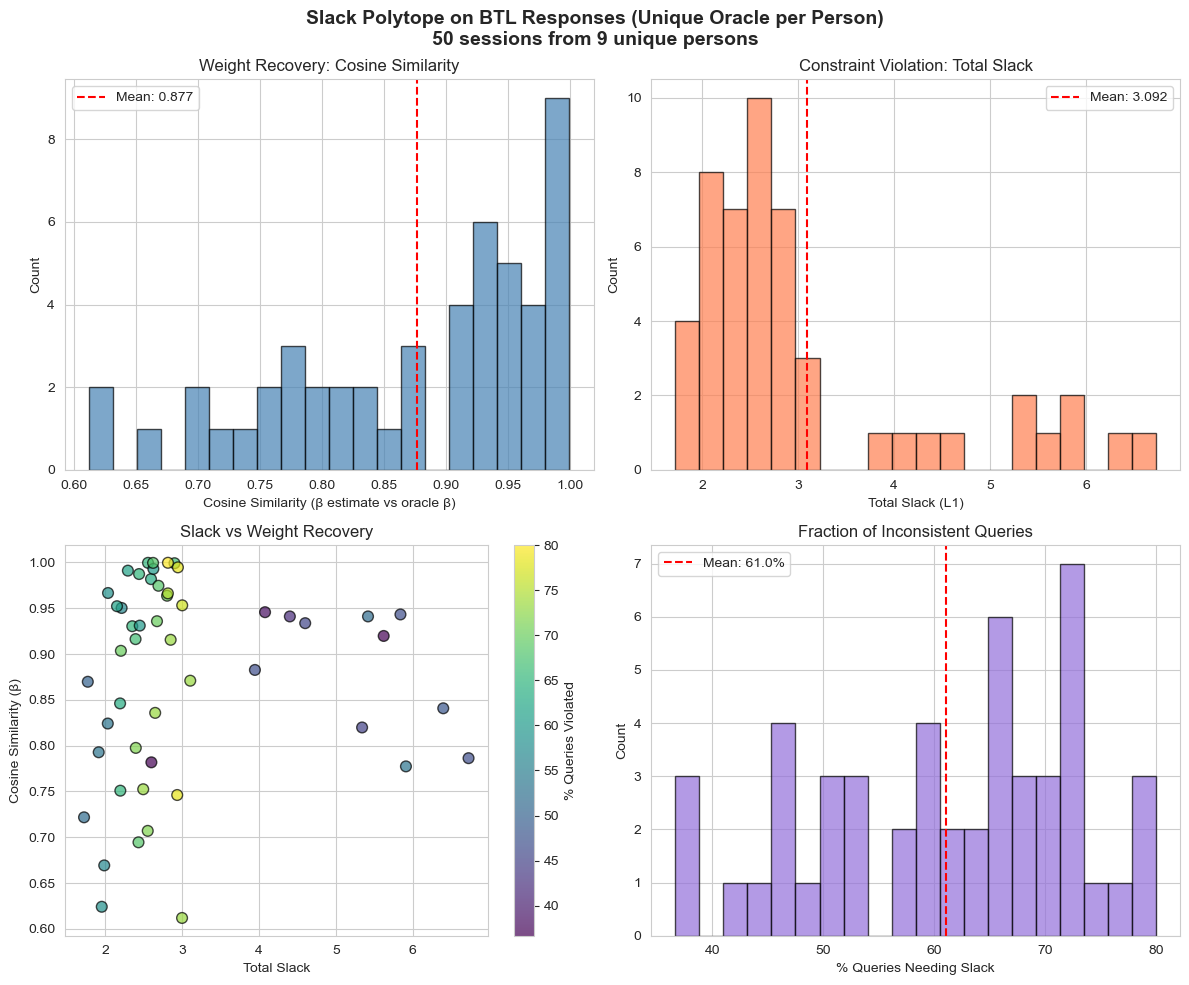


ORACLE BETAS BY PERSON
Person     | elderlyDep    lifeYrs    obesity    workhrs    waiting
---------------------------------------------------------------------------
1          |     +0.000     +0.351     +0.325     +0.325     +0.000
2          |     +0.503     +0.000     -0.000     -0.239     -0.257
3          |     +0.222     +0.000     +0.147     +0.324     +0.307
4          |     +0.279     +0.000     -0.467     -0.255     -0.000
5          |     +0.346     -0.325     -0.082     +0.133     +0.115
6          |     -0.273     +0.161     -0.151     +0.281     +0.134
7          |     -0.189     +0.000     -0.322     -0.490     -0.000
8          |     +0.188     -0.557     +0.145     +0.110     +0.000
9          |     -0.139     +0.581     +0.114     -0.166     +0.000


In [ ]:
# ============================================================================
# EVALUATION: Slack Polytope on 50 Individual Sessions (BTL responses)
# ============================================================================
#
# For each person-session:
# 1. Use a UNIQUE oracle beta per PERSON (same across all their sessions)
# 2. Generate BTL responses using their personal oracle
# 3. Apply minimal slack algorithm
# 4. Record cosine similarity and total slack
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Get sessions with enough comparisons
session_counts = df.groupby(['id', 'sessionid']).size().reset_index(name='count')
good_sessions = session_counts[session_counts['count'] >= 50].head(50)
print(f"Analyzing {len(good_sessions)} person-sessions")

# Get unique person IDs
unique_persons = good_sessions['id'].unique()
print(f"Unique persons: {len(unique_persons)}")
print("Each PERSON gets a unique oracle beta (same across all their sessions)")
print()

def generate_random_beta(dim=5, sparsity=0.3):
    """
    Generate a random beta vector with:
    - Random signs (some features preferred high, some low)
    - Random magnitudes from Dirichlet (sum of |beta| = 1)
    - Optional sparsity (some weights near zero)
    """
    # Random magnitudes on simplex
    magnitudes = np.random.dirichlet(np.ones(dim) * 2)  # Slightly concentrated
    
    # Random signs
    signs = np.random.choice([-1, 1], size=dim)
    
    # Apply sparsity (randomly zero out some weights)
    if sparsity > 0:
        mask = np.random.random(dim) > sparsity
        magnitudes = magnitudes * mask
        # Renormalize
        if magnitudes.sum() > 0:
            magnitudes = magnitudes / magnitudes.sum()
    
    return signs * magnitudes

# Pre-generate oracle beta for each UNIQUE person
person_oracles = {}
for person_id in unique_persons:
    beta = generate_random_beta(dim=5, sparsity=0.2)
    V = np.diag(np.sign(beta))
    omega = np.abs(beta)
    if omega.sum() > 0:
        omega_simplex = omega / omega.sum()
    else:
        omega_simplex = np.ones(5) / 5
    
    person_oracles[person_id] = {
        'beta': beta,
        'V': V,
        'omega_simplex': omega_simplex
    }

print(f"Generated oracles for {len(person_oracles)} unique persons")
print()

# Store results
results = []

for idx, row in good_sessions.iterrows():
    person_id, session_id = row['id'], row['sessionid']
    
    # Get this person's oracle (same for all their sessions)
    oracle = person_oracles[person_id]
    person_beta = oracle['beta']
    person_V = oracle['V']
    person_omega_simplex = oracle['omega_simplex']
    
    # Get this person's comparisons for this session
    person_df = df[(df['id'] == person_id) & (df['sessionid'] == session_id)].copy()
    
    # Build comparisons list
    person_comparisons = []
    for _, r in person_df.iterrows():
        left = normalize_features(r, left_cols)
        right = normalize_features(r, right_cols)
        person_comparisons.append({
            'left_features': left,
            'right_features': right,
            'delta': left - right
        })
    
    # Generate BTL responses using this person's beta
    person_transcript = []
    for comp in person_comparisons:
        delta = comp['delta']
        score = np.dot(person_beta, delta)  # Use person-specific beta
        prob_left = sigmoid(score)
        chose_left = np.random.random() < prob_left
        
        # Create PairwiseQuery
        left_patient = Patient(*comp['left_features'])
        right_patient = Patient(*comp['right_features'])
        query = PairwiseQuery(left_patient, right_patient)
        response = 'left' if chose_left else 'right'
        
        person_transcript.append((query, response))
    
    # Apply minimal slack with person-specific V
    slack_result = compute_minimal_slack(
        person_transcript,
        tau=TAU,
        tau_prime=TAU_PRIME,
        lambda_x=LAMBDA_X,
        V=person_V,
        dim=5
    )
    
    # Compute cosine similarity (comparing omega estimates)
    cos_sim = np.dot(slack_result.omega, person_omega_simplex) / (
        np.linalg.norm(slack_result.omega) * np.linalg.norm(person_omega_simplex) + 1e-10
    )
    
    # L1 error on omega
    l1_error = np.abs(slack_result.omega - person_omega_simplex).sum()
    
    # Also compare recovered beta
    beta_estimated = person_V @ slack_result.omega
    beta_cos_sim = np.dot(beta_estimated, person_beta) / (
        np.linalg.norm(beta_estimated) * np.linalg.norm(person_beta) + 1e-10
    )
    
    results.append({
        'person_id': person_id,
        'session_id': session_id,
        'n_queries': len(person_transcript),
        'total_slack': slack_result.total_slack,
        'n_violated': slack_result.n_violated_queries,
        'pct_violated': 100 * slack_result.n_violated_queries / len(person_transcript),
        'cosine_sim_omega': cos_sim,
        'cosine_sim_beta': beta_cos_sim,
        'l1_error': l1_error,
        'is_consistent': slack_result.is_consistent,
        'oracle_beta': person_beta,
        'estimated_omega': slack_result.omega,
    })

results_df = pd.DataFrame(results)
print(f"Processed {len(results_df)} sessions")
print()

# ============================================================================
# Summary Statistics
# ============================================================================
print("=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)
print(f"Cosine Sim (beta): mean={results_df['cosine_sim_beta'].mean():.4f}, "
      f"std={results_df['cosine_sim_beta'].std():.4f}, "
      f"min={results_df['cosine_sim_beta'].min():.4f}, "
      f"max={results_df['cosine_sim_beta'].max():.4f}")
print(f"L1 Error:           mean={results_df['l1_error'].mean():.4f}, "
      f"std={results_df['l1_error'].std():.4f}")
print(f"Total Slack:        mean={results_df['total_slack'].mean():.4f}, "
      f"std={results_df['total_slack'].std():.4f}")
print(f"% Queries Violated: mean={results_df['pct_violated'].mean():.1f}%, "
      f"std={results_df['pct_violated'].std():.1f}%")
print(f"Fully Consistent:   {results_df['is_consistent'].sum()} / {len(results_df)}")
print()

# ============================================================================
# Plotting
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Histogram of Cosine Similarity (beta)
ax1 = axes[0, 0]
ax1.hist(results_df['cosine_sim_beta'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(results_df['cosine_sim_beta'].mean(), color='red', linestyle='--', 
            label=f'Mean: {results_df["cosine_sim_beta"].mean():.3f}')
ax1.set_xlabel('Cosine Similarity (β estimate vs oracle β)')
ax1.set_ylabel('Count')
ax1.set_title('Weight Recovery: Cosine Similarity')
ax1.legend()

# 2. Histogram of Total Slack
ax2 = axes[0, 1]
ax2.hist(results_df['total_slack'], bins=20, edgecolor='black', alpha=0.7, color='coral')
ax2.axvline(results_df['total_slack'].mean(), color='red', linestyle='--',
            label=f'Mean: {results_df["total_slack"].mean():.3f}')
ax2.set_xlabel('Total Slack (L1)')
ax2.set_ylabel('Count')
ax2.set_title('Constraint Violation: Total Slack')
ax2.legend()

# 3. Scatter: Slack vs Cosine Similarity
ax3 = axes[1, 0]
scatter = ax3.scatter(results_df['total_slack'], results_df['cosine_sim_beta'], 
                      c=results_df['pct_violated'], cmap='viridis', 
                      alpha=0.7, edgecolor='black', s=60)
ax3.set_xlabel('Total Slack')
ax3.set_ylabel('Cosine Similarity (β)')
ax3.set_title('Slack vs Weight Recovery')
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('% Queries Violated')

# 4. Histogram of % Queries Violated
ax4 = axes[1, 1]
ax4.hist(results_df['pct_violated'], bins=20, edgecolor='black', alpha=0.7, color='mediumpurple')
ax4.axvline(results_df['pct_violated'].mean(), color='red', linestyle='--',
            label=f'Mean: {results_df["pct_violated"].mean():.1f}%')
ax4.set_xlabel('% Queries Needing Slack')
ax4.set_ylabel('Count')
ax4.set_title('Fraction of Inconsistent Queries')
ax4.legend()

plt.suptitle('Slack Polytope on BTL Responses (Unique Oracle per Person)\n'
             f'{len(results_df)} sessions from {len(unique_persons)} unique persons', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# Show oracle betas for each unique person
# ============================================================================
print("\n" + "=" * 70)
print("ORACLE BETAS BY PERSON")
print("=" * 70)
print(f"{'Person':<10} | {'elderlyDep':>10} {'lifeYrs':>10} {'obesity':>10} {'workhrs':>10} {'waiting':>10}")
print("-" * 75)
for person_id in list(unique_persons)[:10]:  # Show first 10 unique persons
    beta = person_oracles[person_id]['beta']
    print(f"{person_id:<10} | {beta[0]:>+10.3f} {beta[1]:>+10.3f} {beta[2]:>+10.3f} {beta[3]:>+10.3f} {beta[4]:>+10.3f}")
if len(unique_persons) > 10:
    print(f"... and {len(unique_persons) - 10} more persons")


In [ ]:
# ============================================================================
# EXPERIMENT: Active Learning (Multi-Frame) -> Bradley-Terry Analysis
# ============================================================================
#
# For 50 random oracle weights:
# 1. Run active learning with tau=tau'=0, logistic noise (multi-frame model)
# 2. Generate 60 queries via BALD query selection
# 3. Collect transcript of noisy responses
# 4. Analyze transcript with Bradley-Terry MLE
# 5. Compare BT weight estimate to oracle
#
# This tests: Can BT recover weights from multi-frame generated data?
# ============================================================================

import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.random.seed(42)

# Parameters
N_ORACLES = 50
N_QUERIES = 60
NOISE_SCALE_DELTA = 0.3  # Logistic noise on Δ
NOISE_SCALE_R = 0.0      # No noise on r for this experiment
TAU_ZERO = 0.0     # tau = 0
TAU_PRIME_ZERO = 0.0  # tau' = 0

print("=" * 70)
print("EXPERIMENT: Active Learning (Multi-Frame) -> BT Analysis")
print("=" * 70)
print(f"Number of oracle weights: {N_ORACLES}")
print(f"Queries per oracle: {N_QUERIES}")
print(f"Noise: logistic, scale_delta={NOISE_SCALE_DELTA}, scale_r={NOISE_SCALE_R}")
print(f"tau={TAU_ZERO}, tau'={TAU_PRIME_ZERO}")
print()

# Store results
experiment_results = []

for trial in range(N_ORACLES):
    # Generate random oracle on simplex
    oracle_weights = np.random.dirichlet(np.ones(5))
    
    # Run active learning to generate transcript
    # Using a simplified version that just collects the transcript
    noise_fn = logistic_noise(scale_delta=NOISE_SCALE_DELTA, scale_r=NOISE_SCALE_R)
    transcript = []
    
    # For active learning, we need posterior samples
    # Start with uniform prior
    posterior_samples = np.random.dirichlet(np.ones(5), size=500)
    
    for q_idx in range(N_QUERIES):
        # Generate candidate queries
        candidates = generate_candidate_queries_normalized(50)
        
        # Select query using BALD (simplified - use first few posterior samples)
        best_query = None
        best_bald = -np.inf
        
        for query in candidates:
            # Compute BALD score
            score = bald_score(
                query, posterior_samples[:100], 
                'logistic', NOISE_SCALE_DELTA, NOISE_SCALE_R,
                TAU_ZERO, TAU_PRIME_ZERO, LAMBDA_X,
                max_samples=50, V=None
            )
            if score > best_bald:
                best_bald = score
                best_query = query
        
        if best_query is None:
            best_query = candidates[0]
        
        # Get oracle response using multi-frame model with logistic noise
        response = predict_response_noisy(
            best_query, oracle_weights, noise_fn,
            tau=TAU_ZERO, tau_prime=TAU_PRIME_ZERO,
            lambda_x=LAMBDA_X, V=None
        )
        
        transcript.append((best_query, response))
        
        # Update posterior (every 10 queries to save time)
        if (q_idx + 1) % 10 == 0 and q_idx < N_QUERIES - 1:
            try:
                posterior_samples, _ = sample_posterior_hit_and_run(
                    transcript, 'logistic', NOISE_SCALE_DELTA, NOISE_SCALE_R,
                    TAU_ZERO, TAU_PRIME_ZERO, LAMBDA_X,
                    n_samples=500, burn_in=200, verbose=False
                )
            except:
                pass  # Keep old samples if MCMC fails
    
    # Count response types
    response_counts = {}
    for _, r in transcript:
        response_counts[r] = response_counts.get(r, 0) + 1
    
    # Analyze transcript with Bradley-Terry MLE
    bt_weights = bt_mle(
        transcript,
        dim=5,
        lambda_x=LAMBDA_X,
        scale=NOISE_SCALE_DELTA,
        l2_theta=0.0,
        seed=trial,
        n_restarts=5
    )
    
    # Compute metrics
    cos_sim_bt = np.dot(bt_weights, oracle_weights) / (
        np.linalg.norm(bt_weights) * np.linalg.norm(oracle_weights) + 1e-10
    )
    l1_error_bt = np.abs(bt_weights - oracle_weights).sum()
    
    # Also get Bayesian posterior mean for comparison
    try:
        final_samples, _ = sample_posterior_hit_and_run(
            transcript, 'logistic', NOISE_SCALE_DELTA, NOISE_SCALE_R,
            TAU_ZERO, TAU_PRIME_ZERO, LAMBDA_X,
            n_samples=500, burn_in=200, verbose=False
        )
        bayes_weights = final_samples.mean(axis=0)
    except:
        bayes_weights = np.ones(5) / 5
    
    cos_sim_bayes = np.dot(bayes_weights, oracle_weights) / (
        np.linalg.norm(bayes_weights) * np.linalg.norm(oracle_weights) + 1e-10
    )
    l1_error_bayes = np.abs(bayes_weights - oracle_weights).sum()
    
    experiment_results.append({
        'trial': trial,
        'oracle': oracle_weights,
        'bt_weights': bt_weights,
        'bayes_weights': bayes_weights,
        'cos_sim_bt': cos_sim_bt,
        'cos_sim_bayes': cos_sim_bayes,
        'l1_error_bt': l1_error_bt,
        'l1_error_bayes': l1_error_bayes,
        'n_left': response_counts.get('left', 0),
        'n_right': response_counts.get('right', 0),
        'n_other': response_counts.get('indifferent', 0) + response_counts.get('incomparable', 0),
    })
    
    if (trial + 1) % 10 == 0:
        print(f"Completed {trial + 1}/{N_ORACLES} trials")

print()
print("=" * 70)
print("RESULTS")
print("=" * 70)

# Convert to DataFrame
exp_df = pd.DataFrame(experiment_results)

print("\nBradley-Terry Recovery:")
print(f"  Cosine Sim: mean={exp_df['cos_sim_bt'].mean():.4f}, std={exp_df['cos_sim_bt'].std():.4f}")
print(f"  L1 Error:   mean={exp_df['l1_error_bt'].mean():.4f}, std={exp_df['l1_error_bt'].std():.4f}")

print("\nBayesian Posterior Mean:")
print(f"  Cosine Sim: mean={exp_df['cos_sim_bayes'].mean():.4f}, std={exp_df['cos_sim_bayes'].std():.4f}")
print(f"  L1 Error:   mean={exp_df['l1_error_bayes'].mean():.4f}, std={exp_df['l1_error_bayes'].std():.4f}")

print("\nResponse Distribution (across all trials):")
print(f"  Left:  {exp_df['n_left'].sum()} ({100*exp_df['n_left'].sum()/(N_ORACLES*N_QUERIES):.1f}%)")
print(f"  Right: {exp_df['n_right'].sum()} ({100*exp_df['n_right'].sum()/(N_ORACLES*N_QUERIES):.1f}%)")
print(f"  Other: {exp_df['n_other'].sum()} ({100*exp_df['n_other'].sum()/(N_ORACLES*N_QUERIES):.1f}%)")

# ============================================================================
# Plotting
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Cosine Similarity Comparison
ax1 = axes[0, 0]
ax1.hist(exp_df['cos_sim_bt'], bins=15, alpha=0.6, label='Bradley-Terry', color='steelblue', edgecolor='black')
ax1.hist(exp_df['cos_sim_bayes'], bins=15, alpha=0.6, label='Bayesian', color='coral', edgecolor='black')
ax1.axvline(exp_df['cos_sim_bt'].mean(), color='steelblue', linestyle='--', linewidth=2)
ax1.axvline(exp_df['cos_sim_bayes'].mean(), color='coral', linestyle='--', linewidth=2)
ax1.set_xlabel('Cosine Similarity to Oracle')
ax1.set_ylabel('Count')
ax1.set_title('Weight Recovery: BT vs Bayesian')
ax1.legend()

# 2. L1 Error Comparison
ax2 = axes[0, 1]
ax2.hist(exp_df['l1_error_bt'], bins=15, alpha=0.6, label='Bradley-Terry', color='steelblue', edgecolor='black')
ax2.hist(exp_df['l1_error_bayes'], bins=15, alpha=0.6, label='Bayesian', color='coral', edgecolor='black')
ax2.axvline(exp_df['l1_error_bt'].mean(), color='steelblue', linestyle='--', linewidth=2)
ax2.axvline(exp_df['l1_error_bayes'].mean(), color='coral', linestyle='--', linewidth=2)
ax2.set_xlabel('L1 Error')
ax2.set_ylabel('Count')
ax2.set_title('Weight Recovery: L1 Error')
ax2.legend()

# 3. Scatter: BT vs Bayesian Cosine Similarity
ax3 = axes[1, 0]
ax3.scatter(exp_df['cos_sim_bayes'], exp_df['cos_sim_bt'], alpha=0.7, edgecolor='black', s=60)
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='y=x')
ax3.set_xlabel('Bayesian Cosine Similarity')
ax3.set_ylabel('BT Cosine Similarity')
ax3.set_title('BT vs Bayesian: Per-Trial Comparison')
ax3.legend()
ax3.set_xlim(0, 1.05)
ax3.set_ylim(0, 1.05)

# 4. Box plot comparison
ax4 = axes[1, 1]
box_data = [exp_df['cos_sim_bt'], exp_df['cos_sim_bayes']]
bp = ax4.boxplot(box_data, labels=['Bradley-Terry', 'Bayesian'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
ax4.set_ylabel('Cosine Similarity')
ax4.set_title('Weight Recovery Distribution')

plt.suptitle(f'Active Learning ({N_QUERIES} queries) + Analysis\n'
             f'Data: Multi-Frame Model, tau={TAU_ZERO}, tau_prime = {TAU_PRIME_ZERO} (logistic noise, scale_Δ={NOISE_SCALE_DELTA})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
bt_wins = (exp_df['cos_sim_bt'] > exp_df['cos_sim_bayes']).sum()
bayes_wins = (exp_df['cos_sim_bayes'] > exp_df['cos_sim_bt']).sum()
print(f"BT better in {bt_wins}/{N_ORACLES} trials")
print(f"Bayesian better in {bayes_wins}/{N_ORACLES} trials")
print(f"Mean improvement (Bayes - BT): {(exp_df['cos_sim_bayes'] - exp_df['cos_sim_bt']).mean():.4f}")


EXPERIMENT: Active Learning (Multi-Frame) -> BT Analysis
Number of oracle weights: 50
Queries per oracle: 60
Noise: logistic, scale_delta=0.3, scale_r=0.0
tau=0.0, tau'=0.0



NameError: name 'NOISE_SCALE' is not defined

In [ ]:
# ============================================================================
# EXPERIMENT: Baseline with tau=tau'=0 (BT-equivalent regime)
# ============================================================================
#
# When tau=tau'=0, the multi-frame model reduces to BT:
# - No indifference region (r always >= 0 = tau)
# - No incomparability region (|Δ| always >= 0 = tau'*r)
# - Only left/right responses
#
# Both BT and Bayesian frame model should perform similarly here.
# ============================================================================

import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(42)

# Parameters
N_ORACLES = 50
N_QUERIES = 60
SCALE_DELTA = 0.3
SCALE_R = 0.1
TAU_EXP = 0.0
TAU_PRIME_EXP = 0.0

print("=" * 70)
print("BASELINE: tau=tau'=0 (BT-equivalent regime)")
print("=" * 70)
print(f"Oracles: {N_ORACLES}, Queries: {N_QUERIES}")
print(f"Noise: scale_Δ={SCALE_DELTA}, scale_r={SCALE_R}")
print(f"tau={TAU_EXP}, tau'={TAU_PRIME_EXP}")
print()

baseline_results = []

for trial in range(N_ORACLES):
    oracle_weights = np.random.dirichlet(np.ones(5))
    
    # Create noise function
    if SCALE_R > 0:
        noise_fn = logistic_noise_2d(SCALE_DELTA, SCALE_R)
    else:
        noise_fn = logistic_noise_delta_only(SCALE_DELTA)
    
    # Generate transcript via active learning
    transcript = []
    posterior_samples = np.random.dirichlet(np.ones(5), size=300)
    
    for q_idx in range(N_QUERIES):
        candidates = generate_candidate_queries_normalized(30)
        
        best_query, best_bald = None, -np.inf
        for query in candidates:
            score = bald_score(
                query, posterior_samples[:50],
                'logistic', SCALE_DELTA, SCALE_R,
                TAU_EXP, TAU_PRIME_EXP, LAMBDA_X,
                max_samples=30, V=None, n_mc_samples=30
            )
            if score > best_bald:
                best_bald, best_query = score, query
        
        if best_query is None:
            best_query = candidates[0]
        
        response = predict_response_noisy(
            best_query, oracle_weights, noise_fn,
            TAU_EXP, LAMBDA_X, TAU_PRIME_EXP, V=None
        )
        transcript.append((best_query, response))
        
        # Update posterior every 10 queries
        if (q_idx + 1) % 10 == 0 and q_idx < N_QUERIES - 1:
            try:
                posterior_samples, _ = sample_posterior_hit_and_run(
                    transcript, 'logistic', SCALE_DELTA, SCALE_R,
                    TAU_EXP, TAU_PRIME_EXP, LAMBDA_X,
                    n_samples=300, burn_in=200, n_mc_samples=30,
                    verbose=False, V=None
                )
            except:
                pass
    
    # BT estimate
    bt_weights = bt_mle(transcript, dim=5, lambda_x=LAMBDA_X, scale=SCALE_DELTA,
                        l2_theta=0.0, seed=trial, n_restarts=3)
    
    # Bayesian estimate
    try:
        final_samples, _ = sample_posterior_hit_and_run(
            transcript, 'logistic', SCALE_DELTA, SCALE_R,
            TAU_EXP, TAU_PRIME_EXP, LAMBDA_X,
            n_samples=300, burn_in=200, n_mc_samples=30,
            verbose=False, V=None
        )
        bayes_weights = final_samples.mean(axis=0)
    except:
        bayes_weights = np.ones(5) / 5
    
    # Metrics
    cos_bt = np.dot(bt_weights, oracle_weights) / (
        np.linalg.norm(bt_weights) * np.linalg.norm(oracle_weights) + 1e-10)
    cos_bayes = np.dot(bayes_weights, oracle_weights) / (
        np.linalg.norm(bayes_weights) * np.linalg.norm(oracle_weights) + 1e-10)
    
    resp_counts = Counter(r for _, r in transcript)
    
    baseline_results.append({
        'cos_bt': cos_bt, 'cos_bayes': cos_bayes,
        'n_left': resp_counts.get('left', 0),
        'n_right': resp_counts.get('right', 0),
        'n_indiff': resp_counts.get('indifferent', 0),
        'n_incomp': resp_counts.get('incomparable', 0),
    })
    
    if (trial + 1) % 10 == 0:
        print(f"Trial {trial+1}/{N_ORACLES}")

baseline_df = pd.DataFrame(baseline_results)

print()
print("=" * 70)
print("RESULTS: tau=tau'=0")
print("=" * 70)
print(f"BT Cosine Sim:     mean={baseline_df['cos_bt'].mean():.4f}, std={baseline_df['cos_bt'].std():.4f}")
print(f"Bayes Cosine Sim:  mean={baseline_df['cos_bayes'].mean():.4f}, std={baseline_df['cos_bayes'].std():.4f}")
print()
print(f"Response distribution (avg per trial):")
print(f"  Left: {baseline_df['n_left'].mean():.1f}, Right: {baseline_df['n_right'].mean():.1f}")
print(f"  Indifferent: {baseline_df['n_indiff'].mean():.1f}, Incomparable: {baseline_df['n_incomp'].mean():.1f}")


BASELINE: tau=tau'=0 (BT-equivalent regime)
Oracles: 30, Queries: 50
Noise: scale_Δ=0.3, scale_r=0.1
tau=0.0, tau'=0.0

Trial 10/30


In [2]:
# ============================================================================
# EXPERIMENT: BT vs Bayesian Frame across tau and tau' levels
# ============================================================================
#
# As tau and tau' increase:
# - More indifferent responses (r < tau)
# - More incomparable responses (|Δ| < tau'*r)
# - BT ignores these, losing information
# - Bayesian frame model uses all 4 response types
#
# Expected: BT gets worse, Bayesian stays good or improves
# ============================================================================

np.random.seed(42)

# Experiment parameters
N_ORACLES_GRID = 20
N_QUERIES_GRID = 50
SCALE_DELTA_GRID = 0.3
SCALE_R_GRID = 0.1

# Grid of tau and tau' values
TAU_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4]
TAU_PRIME_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4]

print("=" * 70)
print("GRID EXPERIMENT: BT vs Bayesian across tau/tau' levels")
print("=" * 70)
print(f"Grid: tau in {TAU_VALUES}, tau' in {TAU_PRIME_VALUES}")
print(f"Per cell: {N_ORACLES_GRID} oracles, {N_QUERIES_GRID} queries each")
print()

grid_results = []

for tau_val in TAU_VALUES:
    for tau_prime_val in TAU_PRIME_VALUES:
        print(f"Running tau={tau_val}, tau'={tau_prime_val}...", end=' ')
        
        cell_results = []
        
        for trial in range(N_ORACLES_GRID):
            oracle_weights = np.random.dirichlet(np.ones(5))
            
            if SCALE_R_GRID > 0:
                noise_fn = logistic_noise_2d(SCALE_DELTA_GRID, SCALE_R_GRID)
            else:
                noise_fn = logistic_noise_delta_only(SCALE_DELTA_GRID)
            
            # Generate transcript
            transcript = []
            posterior_samples = np.random.dirichlet(np.ones(5), size=200)
            
            for q_idx in range(N_QUERIES_GRID):
                candidates = generate_candidate_queries_normalized(20)
                
                best_query, best_bald = None, -np.inf
                for query in candidates:
                    score = bald_score(
                        query, posterior_samples[:30],
                        'logistic', SCALE_DELTA_GRID, SCALE_R_GRID,
                        tau_val, tau_prime_val, LAMBDA_X,
                        max_samples=20, V=None, n_mc_samples=20
                    )
                    if score > best_bald:
                        best_bald, best_query = score, query
                
                if best_query is None:
                    best_query = candidates[0]
                
                response = predict_response_noisy(
                    best_query, oracle_weights, noise_fn,
                    tau_val, LAMBDA_X, tau_prime_val, V=None
                )
                transcript.append((best_query, response))
                
                if (q_idx + 1) % 15 == 0 and q_idx < N_QUERIES_GRID - 1:
                    try:
                        posterior_samples, _ = sample_posterior_hit_and_run(
                            transcript, 'logistic', SCALE_DELTA_GRID, SCALE_R_GRID,
                            tau_val, tau_prime_val, LAMBDA_X,
                            n_samples=200, burn_in=100, n_mc_samples=20,
                            verbose=False, V=None
                        )
                    except:
                        pass
            
            # BT estimate (only uses left/right)
            bt_weights = bt_mle(transcript, dim=5, lambda_x=LAMBDA_X,
                                scale=SCALE_DELTA_GRID, l2_theta=0.0,
                                seed=trial, n_restarts=2)
            
            # Bayesian estimate
            try:
                final_samples, _ = sample_posterior_hit_and_run(
                    transcript, 'logistic', SCALE_DELTA_GRID, SCALE_R_GRID,
                    tau_val, tau_prime_val, LAMBDA_X,
                    n_samples=200, burn_in=100, n_mc_samples=20,
                    verbose=False, V=None
                )
                bayes_weights = final_samples.mean(axis=0)
            except:
                bayes_weights = np.ones(5) / 5
            
            cos_bt = np.dot(bt_weights, oracle_weights) / (
                np.linalg.norm(bt_weights) * np.linalg.norm(oracle_weights) + 1e-10)
            cos_bayes = np.dot(bayes_weights, oracle_weights) / (
                np.linalg.norm(bayes_weights) * np.linalg.norm(oracle_weights) + 1e-10)
            
            resp_counts = Counter(r for _, r in transcript)
            n_binary = resp_counts.get('left', 0) + resp_counts.get('right', 0)
            
            cell_results.append({
                'cos_bt': cos_bt, 'cos_bayes': cos_bayes,
                'n_binary': n_binary,
                'n_indiff': resp_counts.get('indifferent', 0),
                'n_incomp': resp_counts.get('incomparable', 0),
            })
        
        # Aggregate
        cell_df = pd.DataFrame(cell_results)
        grid_results.append({
            'tau': tau_val,
            'tau_prime': tau_prime_val,
            'bt_mean': cell_df['cos_bt'].mean(),
            'bt_std': cell_df['cos_bt'].std(),
            'bayes_mean': cell_df['cos_bayes'].mean(),
            'bayes_std': cell_df['cos_bayes'].std(),
            'pct_binary': 100 * cell_df['n_binary'].mean() / N_QUERIES_GRID,
            'pct_indiff': 100 * cell_df['n_indiff'].mean() / N_QUERIES_GRID,
            'pct_incomp': 100 * cell_df['n_incomp'].mean() / N_QUERIES_GRID,
        })
        print(f"BT={cell_df['cos_bt'].mean():.3f}, Bayes={cell_df['cos_bayes'].mean():.3f}")

grid_df = pd.DataFrame(grid_results)
print()
print("Grid complete!")


NameError: name 'np' is not defined

In [1]:
# ============================================================================
# VISUALIZATION: BT vs Bayesian across tau/tau' levels
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Create pivot tables for heatmaps
bt_pivot = grid_df.pivot(index='tau', columns='tau_prime', values='bt_mean')
bayes_pivot = grid_df.pivot(index='tau', columns='tau_prime', values='bayes_mean')
diff_pivot = grid_df.pivot(index='tau', columns='tau_prime', 
                           values='bayes_mean').values - grid_df.pivot(
                           index='tau', columns='tau_prime', values='bt_mean').values

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Heatmap: BT performance
ax1 = axes[0, 0]
sns.heatmap(bt_pivot, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0.5, vmax=1.0, ax=ax1, cbar_kws={'label': 'Cosine Sim'})
ax1.set_title('Bradley-Terry Performance')
ax1.set_xlabel("tau'")
ax1.set_ylabel('tau')

# Heatmap: Bayesian performance
ax2 = axes[0, 1]
sns.heatmap(bayes_pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, ax=ax2, cbar_kws={'label': 'Cosine Sim'})
ax2.set_title('Bayesian Frame Model Performance')
ax2.set_xlabel("tau'")
ax2.set_ylabel('tau')

# Heatmap: Difference (Bayes - BT)
ax3 = axes[0, 2]
diff_df = pd.DataFrame(diff_pivot, index=bt_pivot.index, columns=bt_pivot.columns)
sns.heatmap(diff_df, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=ax3, cbar_kws={'label': 'Bayes - BT'})
ax3.set_title('Advantage: Bayes - BT')
ax3.set_xlabel("tau'")
ax3.set_ylabel('tau')

# Line plot: Performance vs tau (averaged over tau')
ax4 = axes[1, 0]
tau_summary = grid_df.groupby('tau').agg({'bt_mean': 'mean', 'bayes_mean': 'mean'}).reset_index()
ax4.plot(tau_summary['tau'], tau_summary['bt_mean'], 'o-', label='BT', color='steelblue', linewidth=2)
ax4.plot(tau_summary['tau'], tau_summary['bayes_mean'], 's-', label='Bayesian', color='coral', linewidth=2)
ax4.set_xlabel('tau (intensity threshold)')
ax4.set_ylabel('Mean Cosine Similarity')
ax4.set_title('Performance vs tau (avg over tau\')')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Line plot: Performance vs tau' (averaged over tau)
ax5 = axes[1, 1]
taup_summary = grid_df.groupby('tau_prime').agg({'bt_mean': 'mean', 'bayes_mean': 'mean'}).reset_index()
ax5.plot(taup_summary['tau_prime'], taup_summary['bt_mean'], 'o-', label='BT', color='steelblue', linewidth=2)
ax5.plot(taup_summary['tau_prime'], taup_summary['bayes_mean'], 's-', label='Bayesian', color='coral', linewidth=2)
ax5.set_xlabel("tau' (resolvability threshold)")
ax5.set_ylabel('Mean Cosine Similarity')
ax5.set_title("Performance vs tau' (avg over tau)")
ax5.legend()
ax5.grid(True, alpha=0.3)

# Bar plot: Response distribution by tau
ax6 = axes[1, 2]
resp_by_tau = grid_df.groupby('tau').agg({
    'pct_binary': 'mean', 'pct_indiff': 'mean', 'pct_incomp': 'mean'
}).reset_index()
x = np.arange(len(resp_by_tau))
width = 0.25
ax6.bar(x - width, resp_by_tau['pct_binary'], width, label='Left/Right', color='steelblue')
ax6.bar(x, resp_by_tau['pct_indiff'], width, label='Indifferent', color='gray')
ax6.bar(x + width, resp_by_tau['pct_incomp'], width, label='Incomparable', color='coral')
ax6.set_xlabel('tau')
ax6.set_ylabel('% of responses')
ax6.set_title('Response Distribution by tau')
ax6.set_xticks(x)
ax6.set_xticklabels(resp_by_tau['tau'])
ax6.legend()

plt.suptitle('BT vs Bayesian Frame Model: Effect of tau and tau\'\n'
             'Higher tau/tau\' → More indiff/incomp responses → BT loses info',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(grid_df.to_string(index=False))


NameError: name 'grid_df' is not defined